# Pipeline Xử Lý Dataset Ped2 (UCSD) — RAFT Thay FlowNet2

Pipeline theo đúng thiết kế của **HF2VAD** (`1402_ImageNet-Big-Application`):

1. **Load dataset** Ped2 (cấu trúc thư mục chuẩn)
2. **Extract BBoxes** dùng Faster R-CNN (tương đương bước mmdet Cascade RCNN)
3. **Extract Optical Flows** dùng **RAFT** (thay thế FlowNet2) — lưu `.npy` cùng format
4. **Visualize** kết quả trên từng bbox

---
```
data/
└── ped2/
    ├── training/frames/<video_folder>/*.tif
    ├── testing/frames/<video_folder>/*.tif
    ├── training/flows/<video_folder>/<frame>.npy  ← output RAFT
    └── testing/flows/<video_folder>/<frame>.npy   ← output RAFT
```

## 0. Cài đặt & Import

In [1]:
# Kaggle / Colab: uncomment nếu cần cài
# !pip install torch torchvision tqdm opencv-python-headless matplotlib --quiet

In [2]:
import os
import cv2
import numpy as np
import torch
import torch.nn.functional as F
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

from torchvision.models.optical_flow import raft_large, Raft_Large_Weights
from torchvision.transforms import functional as TF
from torchvision.utils import flow_to_image
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch: 2.10.0+cu128
CUDA available: True


## 1. Cấu hình đường dẫn & Hyperparameters

In [3]:
import torch
from pathlib import Path

INPUT_ROOT = Path("/kaggle/input/datasets/hihnguynth/ucsd-anomaly-dataset/UCSD_Anomaly_Dataset.v1p2")
OUTPUT_ROOT = Path("/kaggle/working/optical_flow_results") # Bắt buộc ghi vào /working/ trên Kaggle

DATASET_NAME = "UCSDped2"   # hoặc "avenue", "shanghaitech"
MODE         = "test"  # "train" hoặc "test"

# ======================================================
# Các tham số theo HF2VAD
# ======================================================
DATASET_CFGS = {
    "UCSDped2": {
        "conf_thr":        0.5,
        "min_area":        10 * 10,
        "cover_thr":       0.6,
        "binary_thr":      18,
        "gauss_mask_size": 3,
        "contour_min_area":10 * 10,
    },
    "avenue": {
        "conf_thr":        0.25,
        "min_area":        40 * 40,
        "cover_thr":       0.6,
        "binary_thr":      18,
        "gauss_mask_size": 5,
        "contour_min_area":40 * 40,
    },
    "shanghaitech": {
        "conf_thr":        0.5,
        "min_area":        8 * 8,
        "cover_thr":       0.65,
        "binary_thr":      15,
        "gauss_mask_size": 5,
        "contour_min_area":40 * 40,
    },
}

# Kích thước resize khi tính flow (giống FlowNet2 gốc)
RAFT_INPUT_SIZE = {
    "UCSDped2":      (768, 1024),   
    "avenue":        (768, 1024),
    "shanghaitech":  (640, 1024),
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

cfg = DATASET_CFGS[DATASET_NAME]
RAFT_H, RAFT_W = RAFT_INPUT_SIZE[DATASET_NAME]

# ======================================================
# ĐỊNH TUYẾN ĐƯỜNG DẪN (PATH ROUTING)
# Đã fix khớp với cấu trúc: UCSDped2/Train/Train001/001.tif
# ======================================================
if MODE == "train":
    FRAMES_ROOT = INPUT_ROOT / DATASET_NAME / "Train"
    FLOWS_ROOT  = OUTPUT_ROOT / DATASET_NAME / "Train"
else:
    FRAMES_ROOT = INPUT_ROOT / DATASET_NAME / "Test"
    FLOWS_ROOT  = OUTPUT_ROOT / DATASET_NAME / "Test"

# Khởi tạo thư mục Output (Không can thiệp vào Input)
FLOWS_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Frames root (Read-only) : {FRAMES_ROOT}")
print(f"Flows output (Writable) : {FLOWS_ROOT}")

# --- KIỂM TRA NHANH TÍNH TOÀN VẸN CỦA DỮ LIỆU ---
if not FRAMES_ROOT.exists():
    print(f"LỖI: Không tìm thấy thư mục dữ liệu gốc tại {FRAMES_ROOT}")
else:
    # Lấy thử một thư mục con (ví dụ Train001) để xác minh
    sample_subdirs = list(FRAMES_ROOT.glob("*"))
    if sample_subdirs:
        print(f"Đã tìm thấy thư mục con, ví dụ: {sample_subdirs[0].name}")
    else:
        print("Thư mục gốc tồn tại nhưng trống rỗng.")

Device: cuda
Frames root (Read-only) : /kaggle/input/datasets/hihnguynth/ucsd-anomaly-dataset/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test
Flows output (Writable) : /kaggle/working/optical_flow_results/UCSDped2/Test
Đã tìm thấy thư mục con, ví dụ: Test001


## 2. Load Dataset (quét frame pairs)

Đây là phần thay thế `get_dataset()` từ `datasets/dataset.py` của HF2VAD.  
Mỗi item = cặp frame liền kề `(frame_i, frame_{i+1})` cùng video.

In [4]:
def scan_frame_pairs(frames_root: Path, extensions=(".tif", ".jpg", ".png", ".bmp")):
    """
    Quét tất cả video folders dưới frames_root.
    Trả về list of (video_name, frame1_path, frame2_path).
    Đây chính xác là logic `context_frame_num=1` của HF2VAD dataset.
    """
    pairs = []
    video_dirs = sorted([d for d in frames_root.iterdir() if d.is_dir()])

    if not video_dirs:
        # Flat structure: tất cả frames nằm thẳng trong frames_root
        all_frames = sorted([f for f in frames_root.iterdir()
                              if f.suffix.lower() in extensions])
        video_dirs_resolved = [(frames_root.name, all_frames)]
    else:
        video_dirs_resolved = []
        for vd in video_dirs:
            frames = sorted([f for f in vd.iterdir() if f.suffix.lower() in extensions])
            if frames:
                video_dirs_resolved.append((vd.name, frames))

    for video_name, frames in video_dirs_resolved:
        for i in range(len(frames) - 1):
            pairs.append((video_name, frames[i], frames[i + 1]))

    return pairs


frame_pairs = scan_frame_pairs(FRAMES_ROOT)
print(f"Tổng cặp frame (pairs): {len(frame_pairs)}")

# Preview
if frame_pairs:
    vn, f1, f2 = frame_pairs[0]
    print(f"Ví dụ pair đầu tiên: video={vn}")
    print(f"  frame1: {f1.name}")
    print(f"  frame2: {f2.name}")
else:
    print("⚠️  Không tìm thấy frame nào. Kiểm tra FRAMES_ROOT.")

Tổng cặp frame (pairs): 3996
Ví dụ pair đầu tiên: video=Test001
  frame1: 001.tif
  frame2: 002.tif


### Kiểm tra nhanh 2 frame đầu

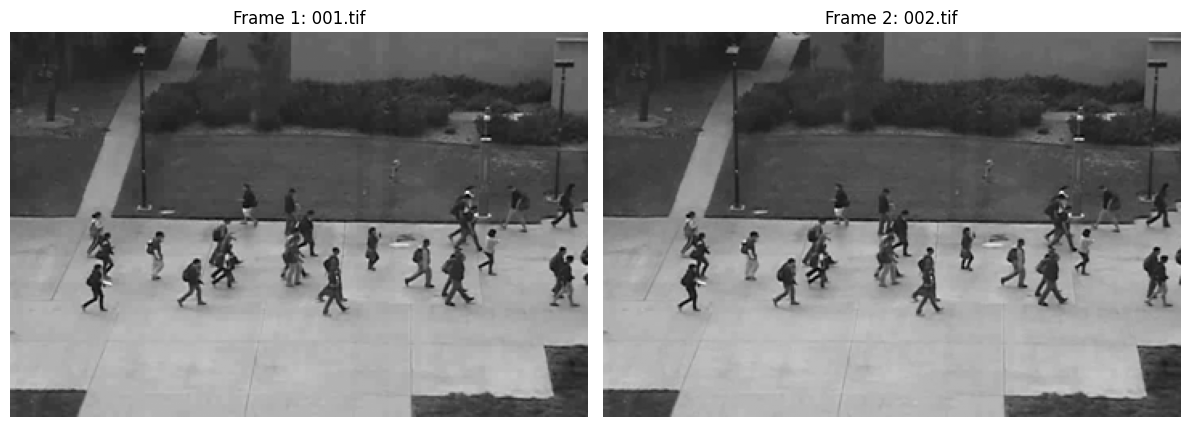

Kích thước frame: (240, 360)


In [5]:
if frame_pairs:
    _, f1_path, f2_path = frame_pairs[0]
    img1 = cv2.imread(str(f1_path), cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(str(f2_path), cv2.IMREAD_GRAYSCALE)

    if img1 is None or img2 is None:
        print("⚠️ cv2 không đọc được .tif — thử PIL")
        from PIL import Image
        img1 = np.array(Image.open(str(f1_path)).convert("L"))
        img2 = np.array(Image.open(str(f2_path)).convert("L"))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img1, cmap="gray"); axes[0].set_title(f"Frame 1: {f1_path.name}"); axes[0].axis("off")
    axes[1].imshow(img2, cmap="gray"); axes[1].set_title(f"Frame 2: {f2_path.name}"); axes[1].axis("off")
    plt.tight_layout(); plt.show()
    print(f"Kích thước frame: {img1.shape}")

## 3. Khởi tạo Models

- **Faster R-CNN** — thay thế Cascade RCNN (mmdet) của pipeline gốc, cùng chức năng detect person bbox
- **RAFT-Large** — thay thế FlowNet2, load pretrained weights từ `torchvision` (không cần download thủ công)

In [6]:
# -------------------------------------------------------------------
# 3a. FASTER R-CNN (object detector) — tương đương Cascade RCNN gốc
# -------------------------------------------------------------------
print("Đang load Faster R-CNN...")
det_weights  = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
detector     = fasterrcnn_resnet50_fpn(weights=det_weights).to(DEVICE).eval()
det_preprocess = det_weights.transforms()
print("✅ Faster R-CNN ready")

# -------------------------------------------------------------------
# 3b. RAFT-Large (optical flow) — thay thế FlowNet2
# -------------------------------------------------------------------
print("\nĐang load RAFT-Large...")
raft_weights = Raft_Large_Weights.DEFAULT
raft_model   = raft_large(weights=raft_weights, progress=True).to(DEVICE).eval()
raft_transforms = raft_weights.transforms()
print("✅ RAFT-Large ready")

print(f"\n--- So sánh với FlowNet2 ---")
print(f"FlowNet2 : ~162M params, pretrained weights 500MB (download thủ công)")
param_count = sum(p.numel() for p in raft_model.parameters())
print(f"RAFT-Large: {param_count/1e6:.1f}M params, pretrained từ torchvision (tự động)")

Đang load Faster R-CNN...
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 226MB/s]


✅ Faster R-CNN ready

Đang load RAFT-Large...
Downloading: "https://download.pytorch.org/models/raft_large_C_T_SKHT_V2-ff5fadd5.pth" to /root/.cache/torch/hub/checkpoints/raft_large_C_T_SKHT_V2-ff5fadd5.pth


100%|██████████| 20.1M/20.1M [00:00<00:00, 93.8MB/s]

✅ RAFT-Large ready

--- So sánh với FlowNet2 ---
FlowNet2 : ~162M params, pretrained weights 500MB (download thủ công)
RAFT-Large: 5.3M params, pretrained từ torchvision (tự động)


## 4. Hàm hỗ trợ BBox

Port trực tiếp từ `extract_bboxes.py` của HF2VAD:
- `get_obj_bboxes()` — lọc theo score + area
- `del_cover_bboxes()` — loại bbox bị overlap quá nhiều
- `get_fg_bboxes()` — phát hiện foreground bằng motion gradient (không cần model)

In [7]:
def read_frame_rgb(path: Path) -> np.ndarray:
    """Đọc frame bất kỳ định dạng → RGB uint8 [H,W,3]"""
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        from PIL import Image
        img = np.array(Image.open(str(path)).convert("RGB"))
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img


def get_obj_bboxes(img_rgb: np.ndarray, detector, cfg: dict, device: str) -> np.ndarray:
    """
    Port từ getObjBboxes() trong extract_bboxes.py.
    Chạy Faster R-CNN, lọc class=person (label=1), score và area.
    Trả về [N, 4] float32 (x1,y1,x2,y2).
    """
    img_tensor = TF.to_tensor(img_rgb).unsqueeze(0).to(device)
    with torch.no_grad():
        preds = detector(img_tensor)[0]

    boxes  = preds["boxes"].cpu().numpy()
    scores = preds["scores"].cpu().numpy()
    labels = preds["labels"].cpu().numpy()

    # Lọc: chỉ lấy person (COCO label=1) + score > conf_thr
    mask = (labels == 1) & (scores >= cfg["conf_thr"])
    boxes = boxes[mask]

    if len(boxes) == 0:
        return np.zeros((0, 4), dtype=np.float32)

    # Lọc theo diện tích tối thiểu
    areas = (boxes[:, 2] - boxes[:, 0] + 1) * (boxes[:, 3] - boxes[:, 1] + 1)
    boxes = boxes[areas >= cfg["min_area"]]

    return boxes.astype(np.float32) if len(boxes) > 0 else np.zeros((0, 4), dtype=np.float32)


def del_cover_bboxes(bboxes: np.ndarray, cfg: dict) -> np.ndarray:
    """
    Port từ delCoverBboxes() trong extract_bboxes.py.
    Loại bỏ bbox nhỏ hơn bị chứa gần hoàn toàn trong bbox lớn hơn.
    """
    if bboxes.shape[0] == 0:
        return bboxes

    cover_thr = cfg["cover_thr"]
    x1, y1, x2, y2 = bboxes[:, 0], bboxes[:, 1], bboxes[:, 2], bboxes[:, 3]
    areas = (x2 - x1 + 1) * (y2 - y1 + 1)
    sort_idx = areas.argsort()   # ascending
    keep = []

    for i in range(len(sort_idx)):
        si = sort_idx[i]
        larger = sort_idx[i + 1:]
        if len(larger) == 0:
            keep.append(si)
            continue
        ix1 = np.maximum(x1[si], x1[larger])
        iy1 = np.maximum(y1[si], y1[larger])
        ix2 = np.minimum(x2[si], x2[larger])
        iy2 = np.minimum(y2[si], y2[larger])
        inter = np.maximum(0, ix2 - ix1 + 1) * np.maximum(0, iy2 - iy1 + 1)
        ratios = inter / areas[si]
        if not np.any(ratios > cover_thr):
            keep.append(si)

    return bboxes[keep].astype(np.float32) if keep else np.zeros((0, 4), dtype=np.float32)


def get_fg_bboxes(frames_bgr: list, obj_bboxes: np.ndarray, cfg: dict) -> np.ndarray:
    """
    Port từ getFgBboxes() trong extract_bboxes.py.
    Dùng temporal gradient để tìm thêm foreground boxes không được detect bởi model.
    """
    area_thr    = cfg["contour_min_area"]
    binary_thr  = cfg["binary_thr"]
    gauss_k     = cfg["gauss_mask_size"]
    extend      = 2

    sum_grad = np.zeros_like(frames_bgr[0], dtype=np.float32)
    for i in range(len(frames_bgr) - 1):
        g1 = cv2.GaussianBlur(frames_bgr[i].astype(np.float32),  (gauss_k, gauss_k), 0)
        g2 = cv2.GaussianBlur(frames_bgr[i+1].astype(np.float32),(gauss_k, gauss_k), 0)
        sum_grad += cv2.absdiff(g1, g2)

    _, binary = cv2.threshold(sum_grad.astype(np.uint8), binary_thr, 255, cv2.THRESH_BINARY)

    # Xóa vùng đã có obj bbox
    for bbox in obj_bboxes:
        bx = bbox.astype(np.int32)
        y1e = max(0, bx[1] - extend);  y2e = min(bx[3] + extend, binary.shape[0] - 1)
        x1e = max(0, bx[0] - extend);  x2e = min(bx[2] + extend, binary.shape[1] - 1)
        binary[y1e:y2e+1, x1e:x2e+1] = 0

    gray = cv2.cvtColor(binary, cv2.COLOR_BGR2GRAY) if len(binary.shape) == 3 else binary
    contours, _ = cv2.findContours(gray, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    fg_boxes = []
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        if (w+1)*(h+1) > area_thr and w > 0 and h > 0 and w/h < 10 and h/w < 10:
            fg_boxes.append([
                max(0, x - extend), max(0, y - extend),
                min(x + w + extend, gray.shape[1] - 1),
                min(y + h + extend, gray.shape[0] - 1)
            ])

    return np.array(fg_boxes, dtype=np.float32) if fg_boxes else np.zeros((0, 4), dtype=np.float32)


print("✅ Các hàm bbox đã sẵn sàng")

✅ Các hàm bbox đã sẵn sàng


## 5. Hàm Extract Optical Flow bằng RAFT

**Thay thế trực tiếp** `extracting_flows()` trong `extract_flows.py` của HF2VAD:

| | FlowNet2 (gốc) | RAFT (bản này) |
|---|---|---|
| Input | `[bs, 3, 2, H, W]` float tensor | `(img1, img2)` sau `raft_transforms` |
| Resize | 1024×768 | 1024×768 (giống nhau) |
| Output | `[H, W, 2]` .npy | `[H, W, 2]` .npy (format giống nhau) |
| Pretrained | Download thủ công 500MB | `torchvision` tự động |
| Iterations | 1 pass | 12 refinement steps (mặc định RAFT) |

In [8]:
def extract_flow_raft(
    img1_rgb: np.ndarray,
    img2_rgb: np.ndarray,
    raft_model,
    raft_transforms,
    target_hw: tuple,
    original_hw: tuple,
    device: str,
) -> np.ndarray:
    """
    Tính optical flow từ img1 → img2 bằng RAFT.
    
    Quy trình giống hệt extract_flows.py gốc:
      1. Resize về target_hw (RAFT_H, RAFT_W)
      2. Chạy model
      3. Resize flow ngược về original_hw (original frame size)
      4. Trả về [H, W, 2] float32 — cùng format với FlowNet2
    
    Args:
        img1_rgb, img2_rgb : [H, W, 3] uint8 RGB
        target_hw          : (H', W') kích thước chạy model
        original_hw        : (H_orig, W_orig) kích thước lưu npy
    Returns:
        flow : [H_orig, W_orig, 2] float32
    """
    H_tgt, W_tgt = target_hw
    H_orig, W_orig = original_hw

    # Resize về kích thước chạy model (giống cv2.resize trong FlowNet2 gốc)
    img1_resized = cv2.resize(img1_rgb, (W_tgt, H_tgt))   # cv2: (W, H)
    img2_resized = cv2.resize(img2_rgb, (W_tgt, H_tgt))

    # Chuyển sang tensor [1, 3, H, W] uint8 rồi qua raft_transforms
    t1 = TF.to_tensor(img1_resized).unsqueeze(0).to(device)  # [1,3,H,W] float [0,1]
    t2 = TF.to_tensor(img2_resized).unsqueeze(0).to(device)

    # raft_transforms chuẩn hoá về [-1, 1] và đảm bảo kích thước chia hết cho 8
    t1_norm, t2_norm = raft_transforms(t1, t2)

    with torch.no_grad():
        # RAFT trả về list flow ở các refinement steps, lấy bước cuối [-1]
        flow_pred = raft_model(t1_norm, t2_norm)[-1]  # [1, 2, H_tgt, W_tgt]

    flow_np = flow_pred[0].permute(1, 2, 0).cpu().numpy()  # [H_tgt, W_tgt, 2]

    # Resize ngược về kích thước gốc (giống cv2.resize(pred_flow, old_size) trong gốc)
    flow_resized = cv2.resize(flow_np, (W_orig, H_orig))    # [H_orig, W_orig, 2]

    # Scale magnitude theo tỉ lệ resize để đơn vị pixel vẫn đúng
    scale_x = W_orig / W_tgt
    scale_y = H_orig / H_tgt
    flow_resized[..., 0] *= scale_x
    flow_resized[..., 1] *= scale_y

    return flow_resized.astype(np.float32)


print("✅ Hàm extract_flow_raft sẵn sàng")

✅ Hàm extract_flow_raft sẵn sàng


## 6. Pipeline Chính: Extract & Lưu Flows

Chạy toàn bộ dataset và lưu `.npy` — **output format giống hệt FlowNet2 gốc**.

In [9]:
def run_extract_flows(
    frame_pairs:    list,
    flows_root:     Path,
    raft_model,
    raft_transforms,
    raft_hw:        tuple,
    device:         str,
    max_samples:    int = None,   # None = xử lý toàn bộ; đặt số nhỏ để debug
):
    """
    Tương đương hàm extracting_flows() trong extract_flows.py của HF2VAD.
    
    Với mỗi cặp (frame_i, frame_{i+1}):
      - Tính RAFT flow
      - Lưu vào flows_root/<video_name>/<frame_name>.npy
    """
    pairs = frame_pairs if max_samples is None else frame_pairs[:max_samples]
    errors = []

    for video_name, f1_path, f2_path in tqdm(pairs, desc="Extracting flows (RAFT)"):
        try:
            img1 = read_frame_rgb(f1_path)
            img2 = read_frame_rgb(f2_path)

            if img1 is None or img2 is None:
                errors.append(str(f1_path))
                continue

            original_hw = (img1.shape[0], img1.shape[1])

            flow = extract_flow_raft(
                img1_rgb      = img1,
                img2_rgb      = img2,
                raft_model    = raft_model,
                raft_transforms = raft_transforms,
                target_hw     = raft_hw,
                original_hw   = original_hw,
                device        = device,
            )

            # Tạo thư mục video nếu chưa có
            save_dir = flows_root / video_name
            save_dir.mkdir(parents=True, exist_ok=True)

            # Lưu với tên frame gốc + .npy (giống gốc: cur_img_name + '.npy')
            save_path = save_dir / (f1_path.name + ".npy")
            np.save(str(save_path), flow)

        except Exception as e:
            errors.append(f"{f1_path}: {e}")

    print(f"\n✅ Hoàn thành. {len(pairs) - len(errors)}/{len(pairs)} flows đã lưu.")
    if errors:
        print(f"⚠️  {len(errors)} lỗi:")
        for e in errors[:5]: print(f"   {e}")


# ===== CHẠY =====
# max_samples=10 để test nhanh; đặt None để xử lý toàn bộ
run_extract_flows(
    frame_pairs     = frame_pairs,
    flows_root      = FLOWS_ROOT,
    raft_model      = raft_model,
    raft_transforms = raft_transforms,
    raft_hw         = (RAFT_H, RAFT_W),
    device          = DEVICE,
    max_samples     = None,      # ← đổi thành None để chạy toàn bộ
)

Extracting flows (RAFT): 100%|██████████| 3996/3996 [30:09<00:00,  2.21it/s]


✅ Hoàn thành. 3996/3996 flows đã lưu.


## 7. Pipeline BBox + Flow kết hợp — Visualize per-object

Phần này kết hợp cả hai bước: detect bbox → crop → extract flow → hiển thị.  
Đây là phần tương đương với việc dùng output của `extract_bboxes.py` + `extract_flows.py` cùng nhau.

In [10]:
def get_letterbox_crop(img_rgb: np.ndarray, x1, y1, x2, y2, margin=0.4):
    """
    Cắt bbox với padding BORDER_REPLICATE (từ code gốc của bạn).
    Trả về (cropped_img, mask, side_length).
    """
    H, W = img_rgb.shape[:2]
    mx = int((x2 - x1) * margin)
    my = int((y2 - y1) * margin)
    x1, x2 = max(0, x1 - mx), min(W, x2 + mx)
    y1, y2 = max(0, y1 - my), min(H, y2 + my)

    w, h = x2 - x1, y2 - y1
    L = max(w, h, 1)

    crop = img_rgb[y1:y2, x1:x2]
    pt = (L - h) // 2;  pb = L - h - pt
    pl = (L - w) // 2;  pr = L - w - pl
    padded = cv2.copyMakeBorder(crop, pt, pb, pl, pr, cv2.BORDER_REPLICATE)

    mask = np.zeros((L, L), dtype=np.float32)
    mask[pt:pt+h, pl:pl+w] = 1.0
    return padded, mask, L


def visualize_bbox_flow(
    video_name:     str,
    frame_paths:    list,   # list of Path, ít nhất 2 frames
    detector,
    raft_model,
    raft_transforms,
    cfg:            dict,
    device:         str,
    raft_hw:        tuple   = (384, 512),
    stc_size:       tuple   = (64, 64),
    max_boxes:      int     = 4,
    conf_override:  float   = None,
):
    """
    Với một cặp frame (frame[0], frame[1]):
      1. Detect bboxes (Faster R-CNN + fg motion)
      2. Với mỗi bbox: crop, tính RAFT flow, hiển thị
    """
    if len(frame_paths) < 2:
        print("Cần ít nhất 2 frames")
        return

    imgs = [read_frame_rgb(p) for p in frame_paths[:2]]
    imgs_bgr = [cv2.cvtColor(img, cv2.COLOR_RGB2BGR) for img in imgs]

    # ---- Bước 1: Detect bboxes ----
    eff_cfg = dict(cfg)
    if conf_override is not None:
        eff_cfg["conf_thr"] = conf_override

    obj_boxes = get_obj_bboxes(imgs[0], detector, eff_cfg, device)
    obj_boxes = del_cover_bboxes(obj_boxes, eff_cfg)
    fg_boxes  = get_fg_bboxes(imgs_bgr, obj_boxes, eff_cfg)

    if len(obj_boxes) > 0 and len(fg_boxes) > 0:
        all_boxes = np.concatenate([obj_boxes, fg_boxes], axis=0)
    elif len(fg_boxes) > 0:
        all_boxes = fg_boxes
    else:
        all_boxes = obj_boxes

    print(f"Video: {video_name} | obj: {len(obj_boxes)}, fg: {len(fg_boxes)}, total: {len(all_boxes)}")

    if len(all_boxes) == 0:
        # Visualize flow toàn frame nếu không có bbox
        print("  → Không có bbox, hiển thị flow toàn frame")
        flow = extract_flow_raft(
            imgs[0], imgs[1], raft_model, raft_transforms,
            raft_hw, (imgs[0].shape[0], imgs[0].shape[1]), device
        )
        flow_t  = torch.from_numpy(flow).permute(2, 0, 1).unsqueeze(0)
        flow_vis = flow_to_image(flow_t).squeeze(0).permute(1, 2, 0).numpy()
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(imgs[0]);    axes[0].set_title("Frame 1");    axes[0].axis("off")
        axes[1].imshow(imgs[1]);    axes[1].set_title("Frame 2");    axes[1].axis("off")
        axes[2].imshow(flow_vis);   axes[2].set_title("RAFT Flow");  axes[2].axis("off")
        plt.tight_layout(); plt.show()
        return

    # ---- Visualize frame + tất cả bboxes ----
    frame_vis = imgs[0].copy()
    for i, box in enumerate(all_boxes[:max_boxes]):
        color = (0, 255, 0) if i < len(obj_boxes) else (255, 165, 0)
        cv2.rectangle(frame_vis,
                      (int(box[0]), int(box[1])), (int(box[2]), int(box[3])),
                      color, 2)
    plt.figure(figsize=(8, 5))
    plt.imshow(frame_vis)
    plt.title(f"{video_name} — Detected BBoxes (xanh=person, cam=fg)")
    plt.axis("off"); plt.tight_layout(); plt.show()

    # ---- Bước 2: Flow per-bbox ----
    for idx, box in enumerate(all_boxes[:max_boxes]):
        x1, y1, x2, y2 = box.astype(int)

        crop1, mask_np, L = get_letterbox_crop(imgs[0], x1, y1, x2, y2)
        crop2, _,       _ = get_letterbox_crop(imgs[1], x1, y1, x2, y2)

        # Tính RAFT flow trên crop (128x128)
        CROP_SIZE = (128, 128)
        flow_crop = extract_flow_raft(
            crop1, crop2, raft_model, raft_transforms,
            target_hw=CROP_SIZE, original_hw=CROP_SIZE, device=device
        )

        # Áp mask BORDER_REPLICATE để loại viền giả
        mask_t = torch.from_numpy(
            cv2.resize(mask_np, CROP_SIZE[::-1], interpolation=cv2.INTER_NEAREST)
        ).unsqueeze(0).unsqueeze(0).to(device)
        flow_t = torch.from_numpy(flow_crop).permute(2, 0, 1).unsqueeze(0).to(device)
        flow_t = flow_t * mask_t

        # Scale magnitude về kích thước STC cuối
        flow_stc = TF.resize(flow_t, list(stc_size), antialias=True) * (stc_size[0] / CROP_SIZE[0])
        crop_stc = cv2.resize(crop1, stc_size)

        flow_vis = flow_to_image(flow_stc).squeeze(0).permute(1, 2, 0).cpu().numpy()
        mag      = np.linalg.norm(flow_t[0].permute(1, 2, 0).cpu().numpy(), axis=-1)

        # Visualize
        label = "person" if idx < len(obj_boxes) else "fg-motion"
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        fig.suptitle(f"BBox #{idx} ({label}) | x1={x1}, y1={y1}, x2={x2}, y2={y2}", fontsize=12)

        axes[0].imshow(crop1);              axes[0].set_title("Crop Frame 1");   axes[0].axis("off")
        axes[1].imshow(crop2);              axes[1].set_title("Crop Frame 2");   axes[1].axis("off")
        axes[2].imshow(flow_vis);           axes[2].set_title("RAFT Flow (RGB)");axes[2].axis("off")
        im = axes[3].imshow(mag, cmap="hot"); axes[3].set_title("Flow Magnitude"); axes[3].axis("off")
        plt.colorbar(im, ax=axes[3], fraction=0.046)
        plt.tight_layout(); plt.show()


print("✅ Hàm visualize_bbox_flow sẵn sàng")

✅ Hàm visualize_bbox_flow sẵn sàng


## 8. Chạy Visualize trên một số video

Chọn 3 video đầu tiên, mỗi video lấy cặp frame đầu tiên để visualize.

In [11]:
# Nhóm lại frame_pairs theo video
from collections import defaultdict
video_frames = defaultdict(list)
for vname, f1, f2 in frame_pairs:
    if f1 not in video_frames[vname]:
        video_frames[vname].append(f1)
    if f2 not in video_frames[vname]:
        video_frames[vname].append(f2)

video_list = sorted(video_frames.keys())
print(f"Tổng số videos: {len(video_list)}")
print(f"Danh sách: {video_list[:10]}")

Tổng số videos: 24
Danh sách: ['Test001', 'Test001_gt', 'Test002', 'Test002_gt', 'Test003', 'Test003_gt', 'Test004', 'Test004_gt', 'Test005', 'Test005_gt']



  Video: Test001 (180 frames)
Video: Test001 | obj: 20, fg: 0, total: 20


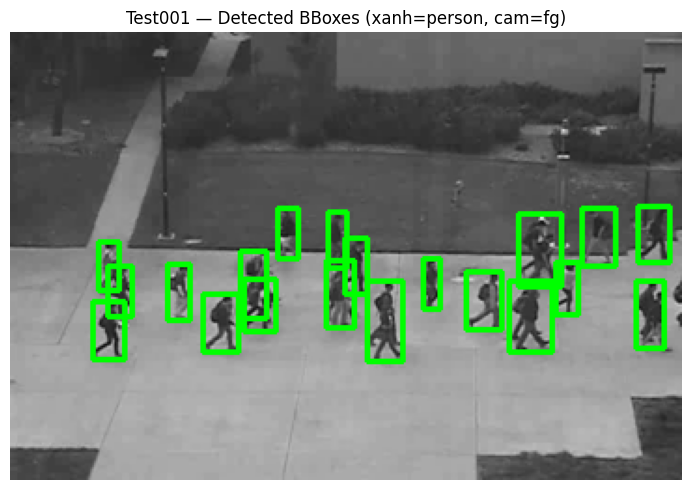

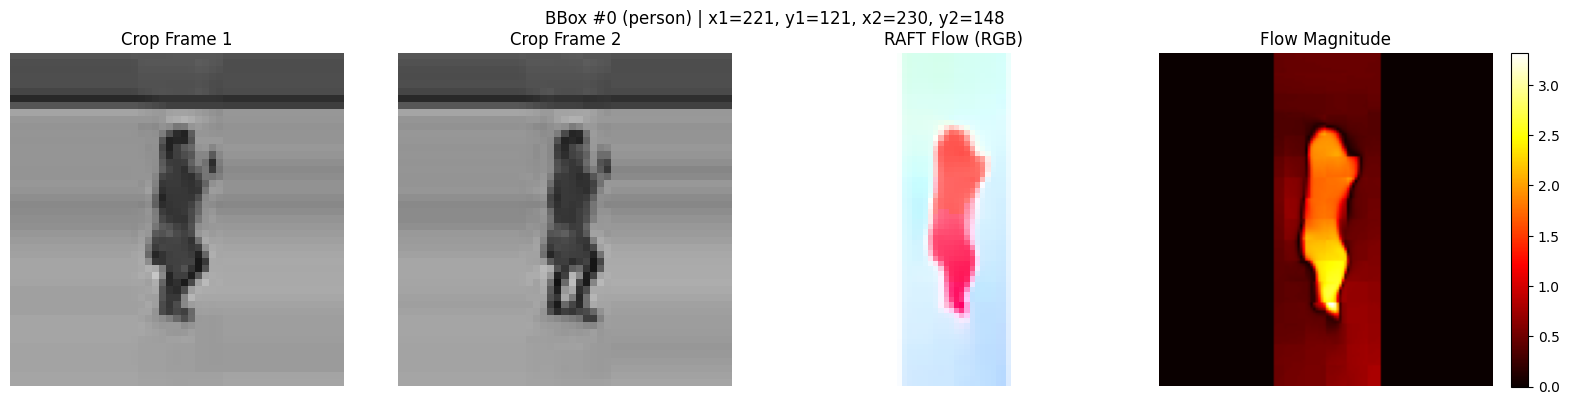

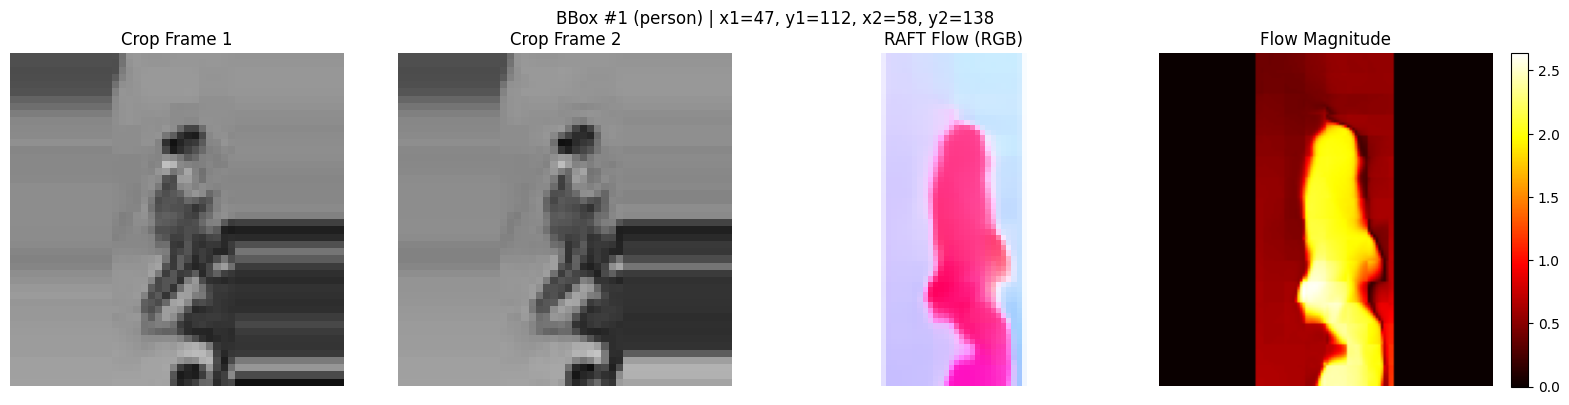

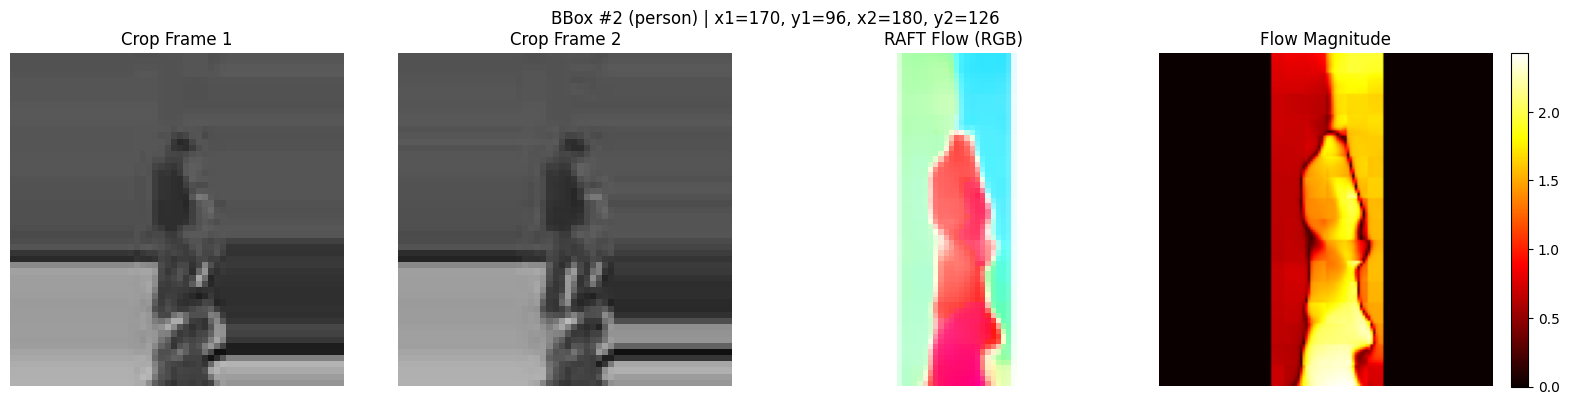

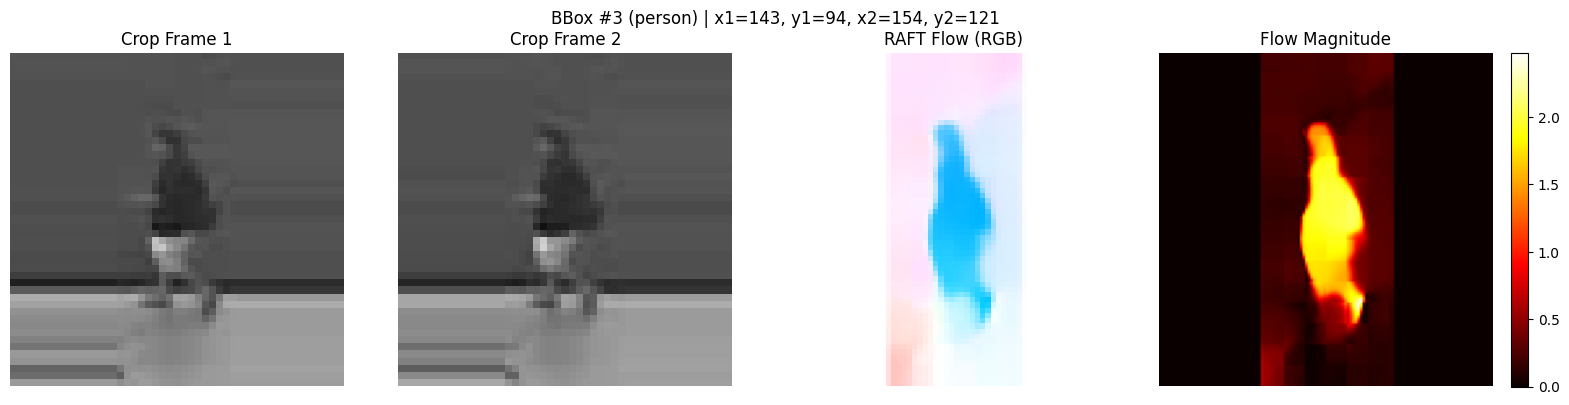

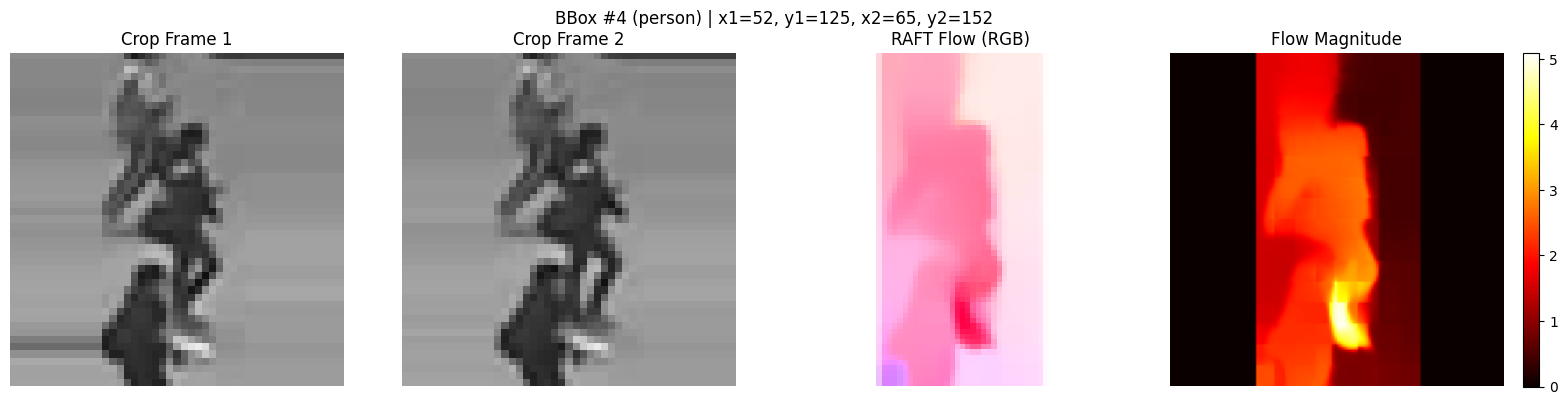

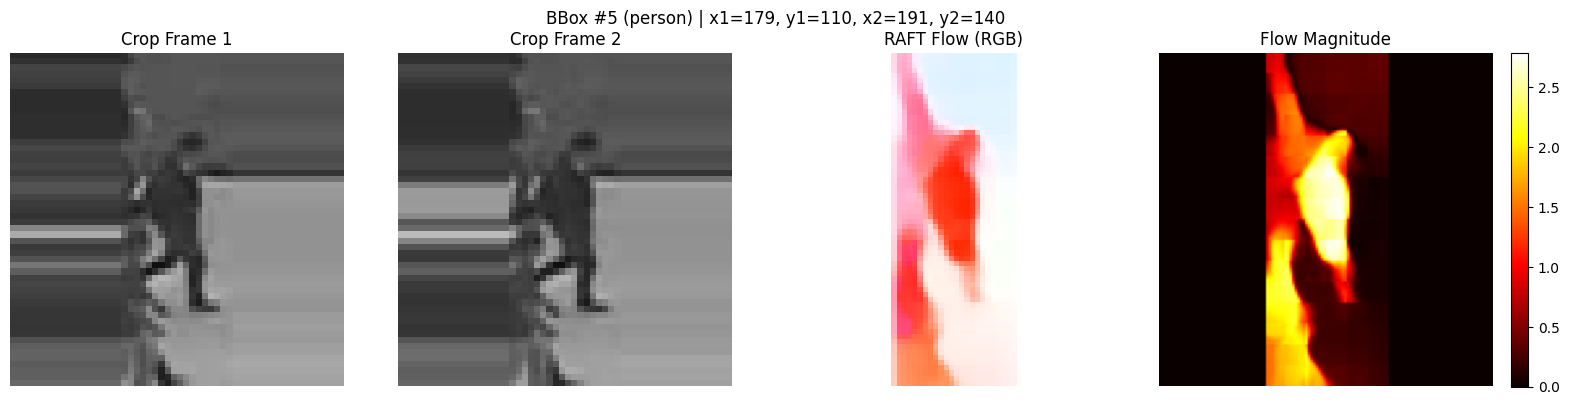

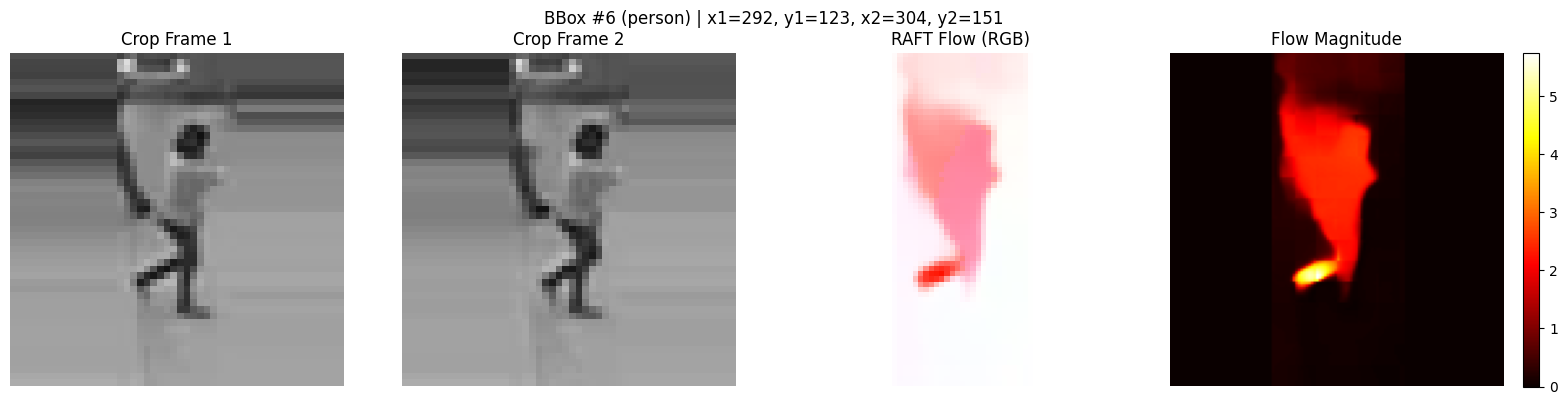

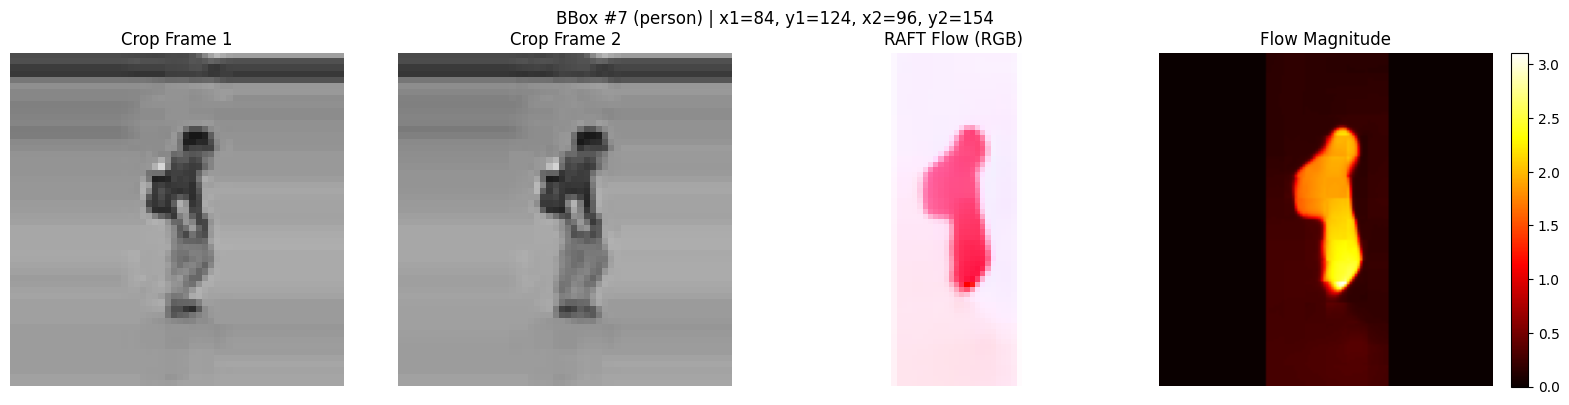

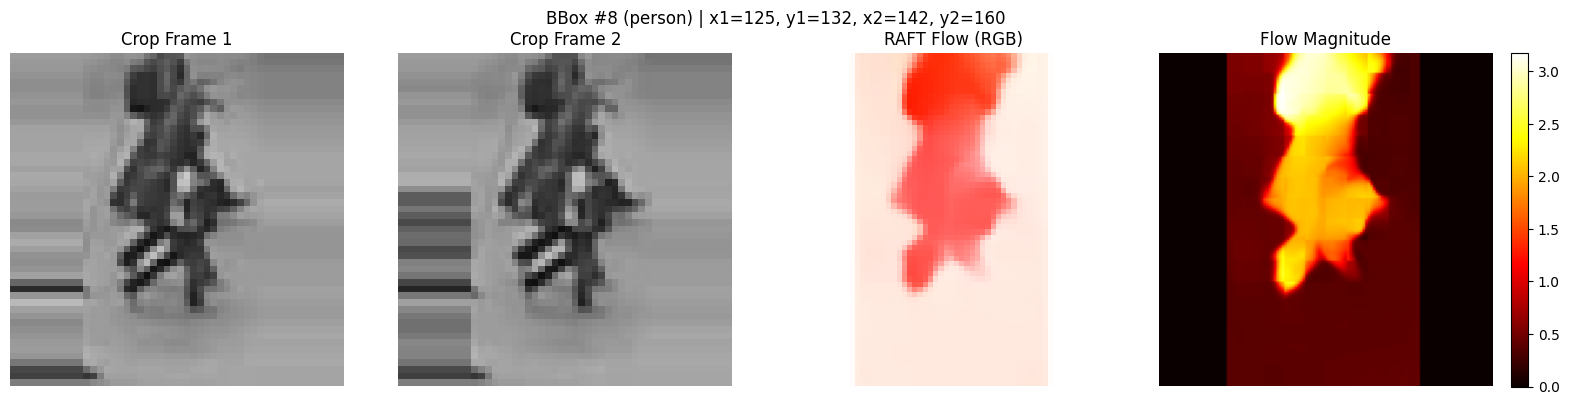

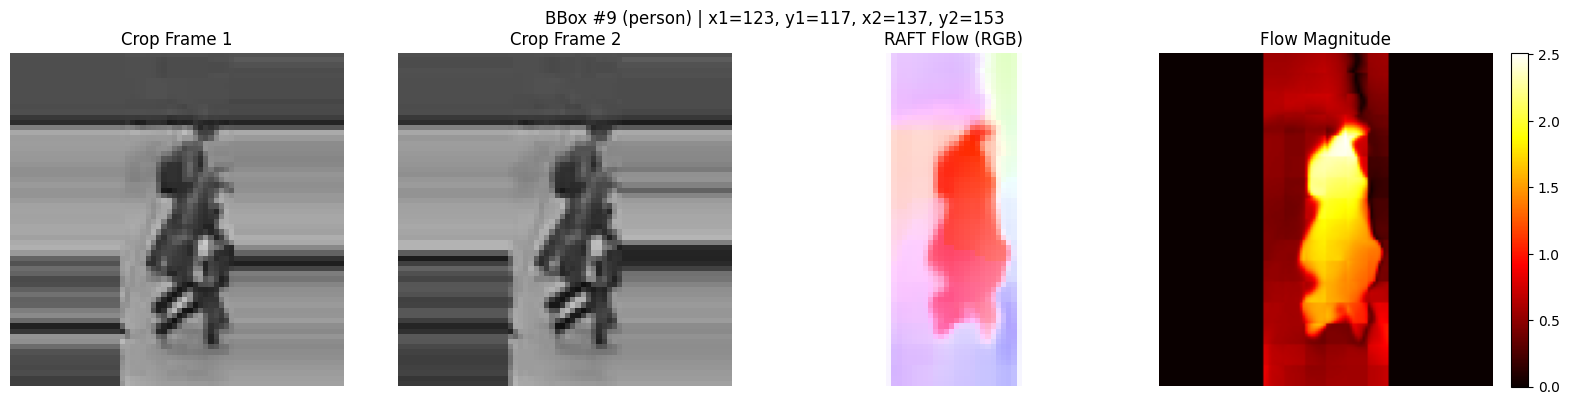

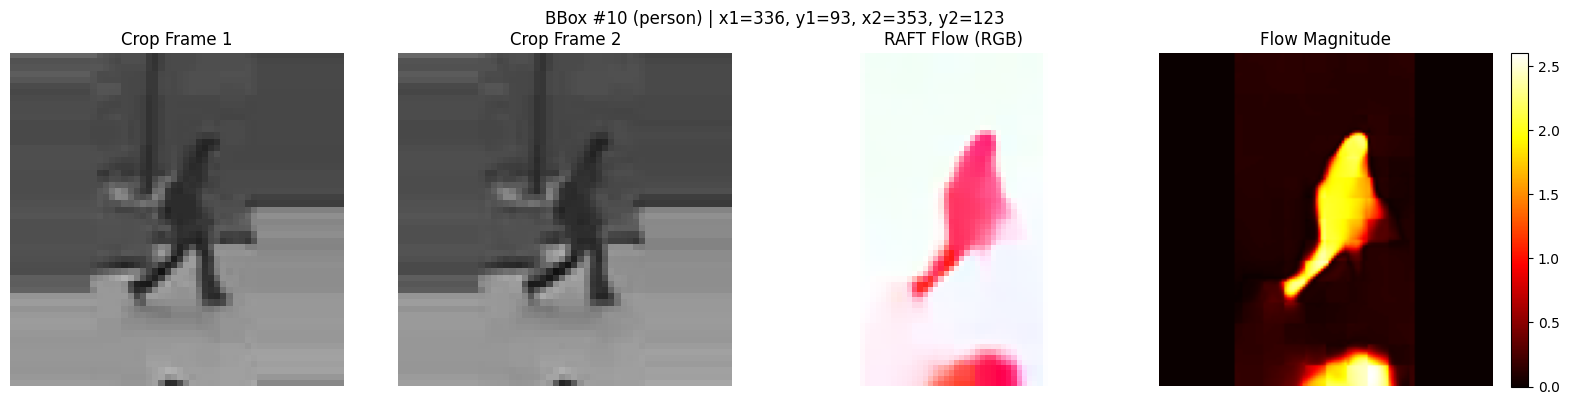

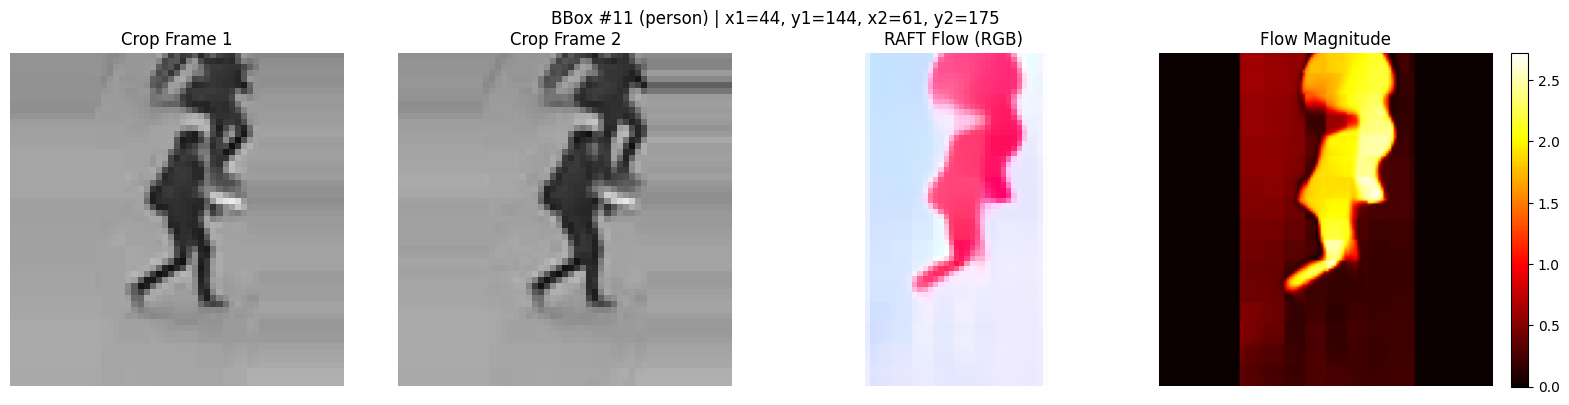

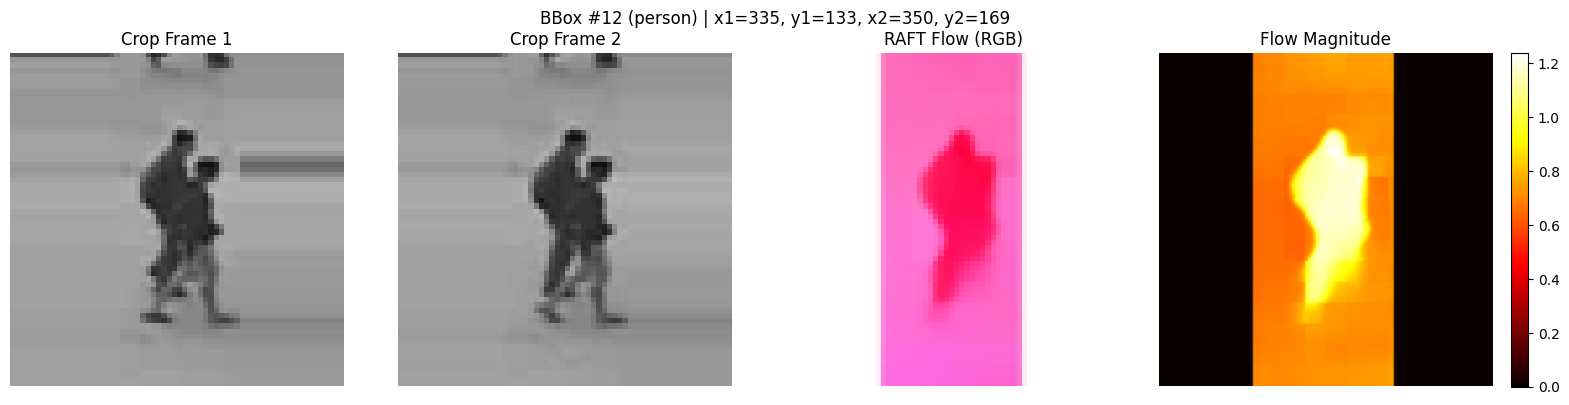

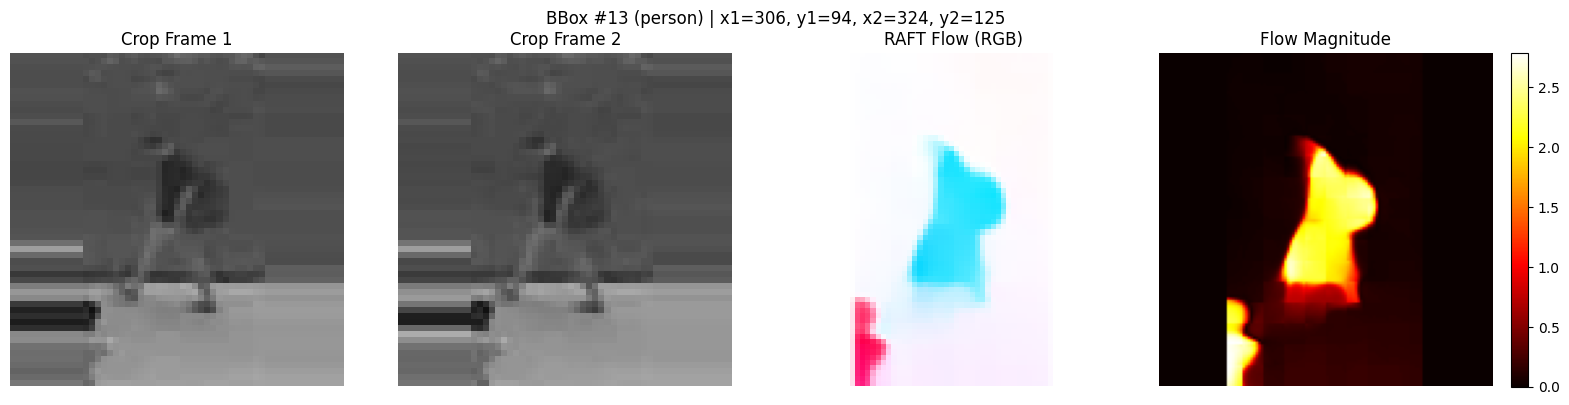

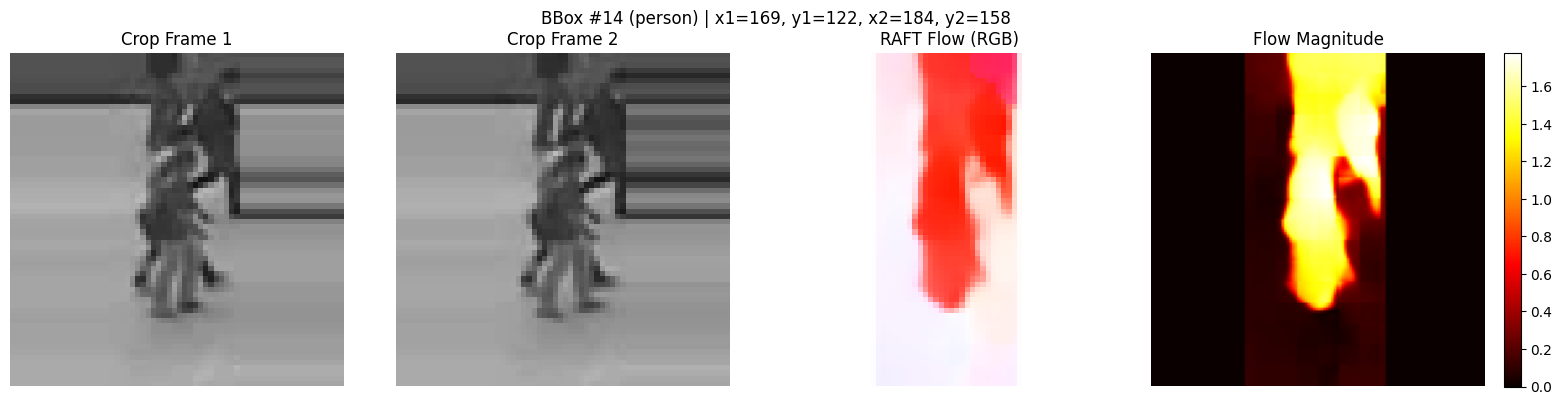

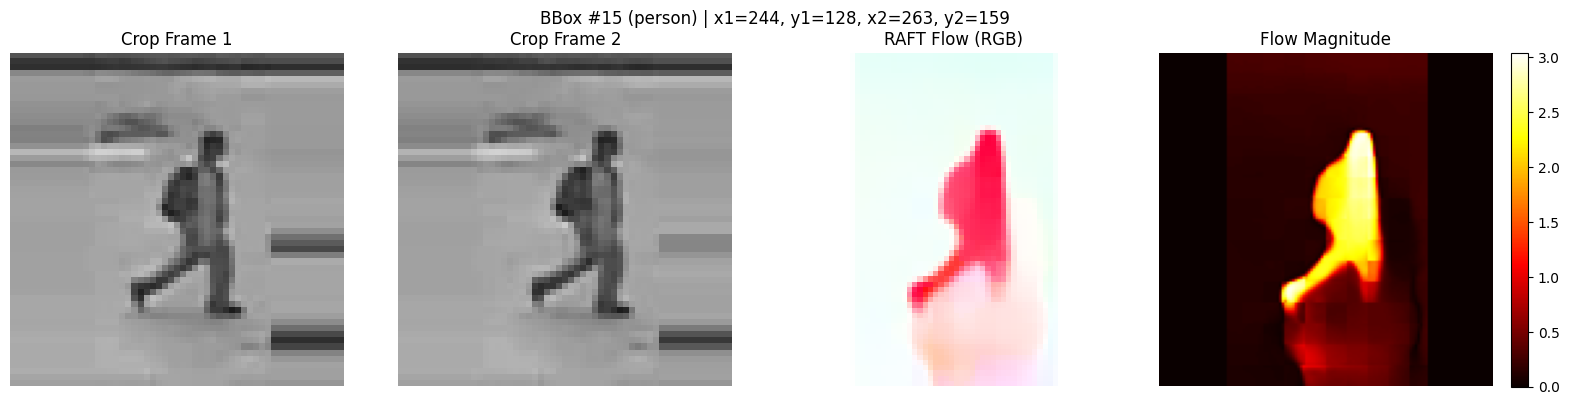

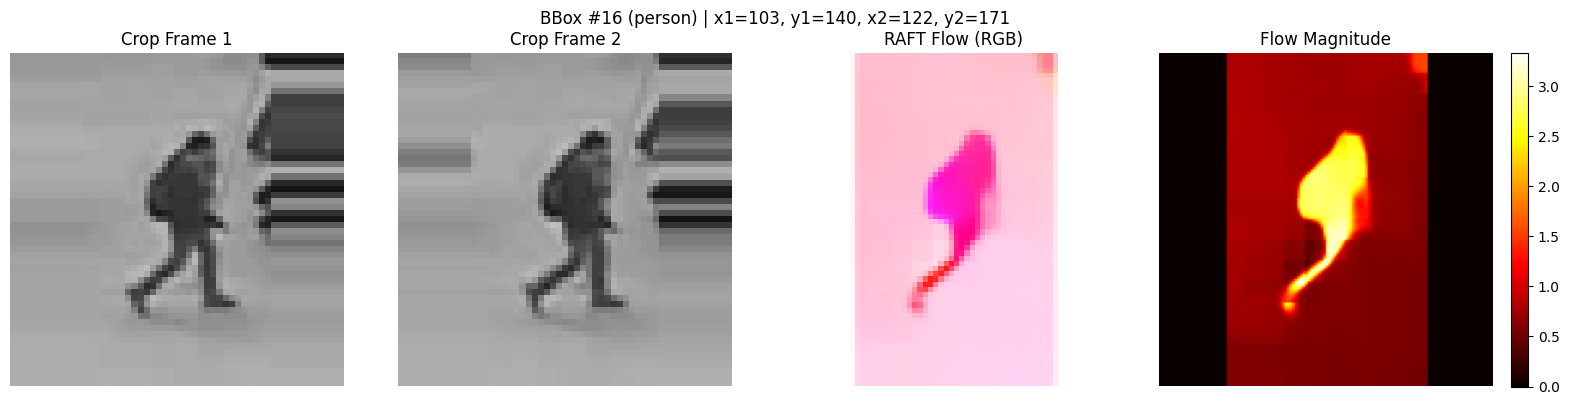

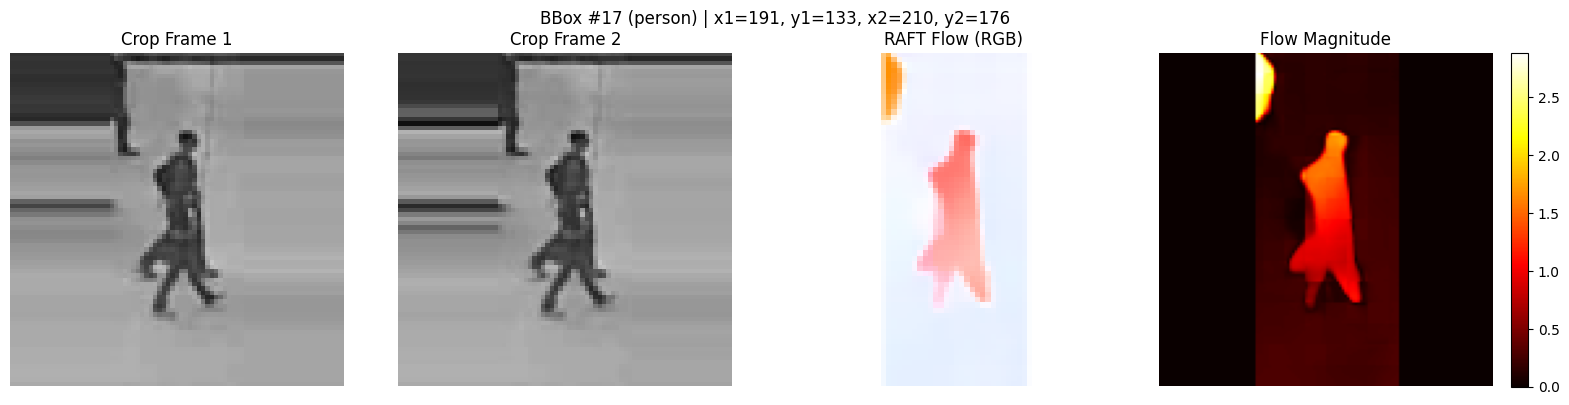

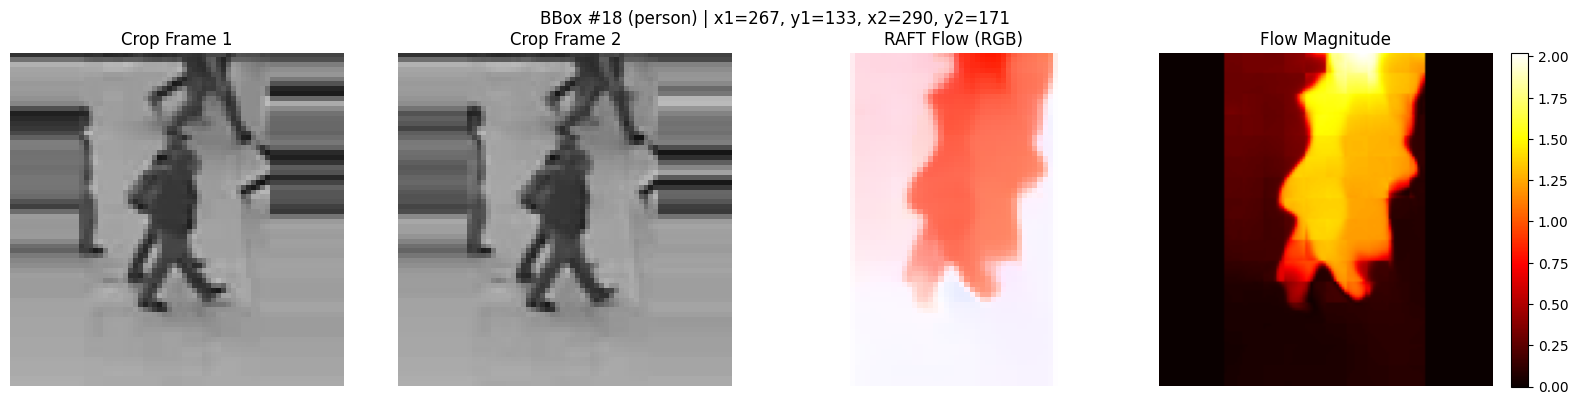

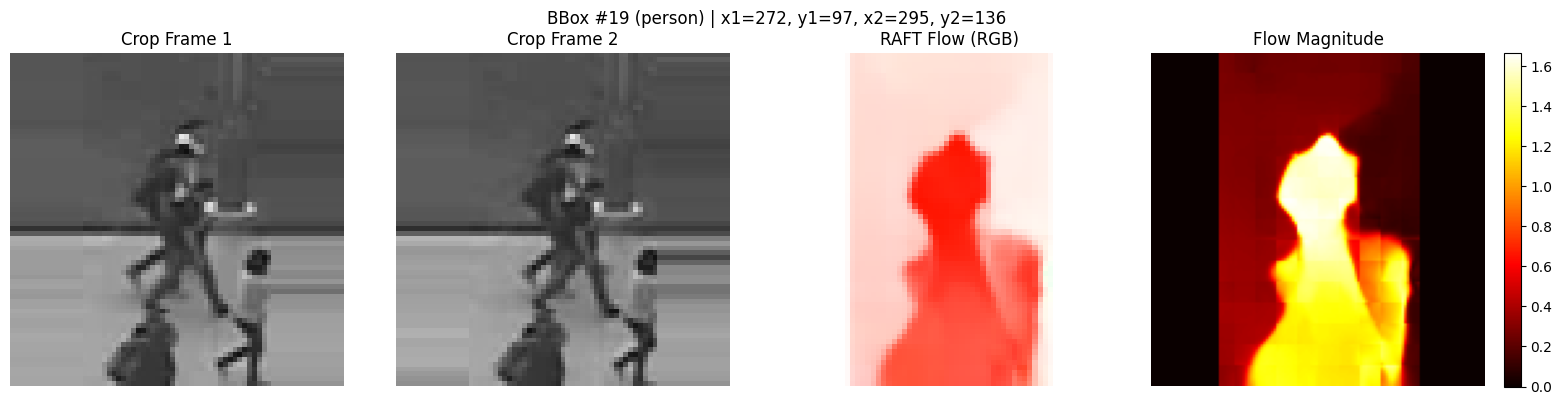


  Video: Test001_gt (180 frames)
Video: Test001_gt | obj: 0, fg: 0, total: 0
  → Không có bbox, hiển thị flow toàn frame


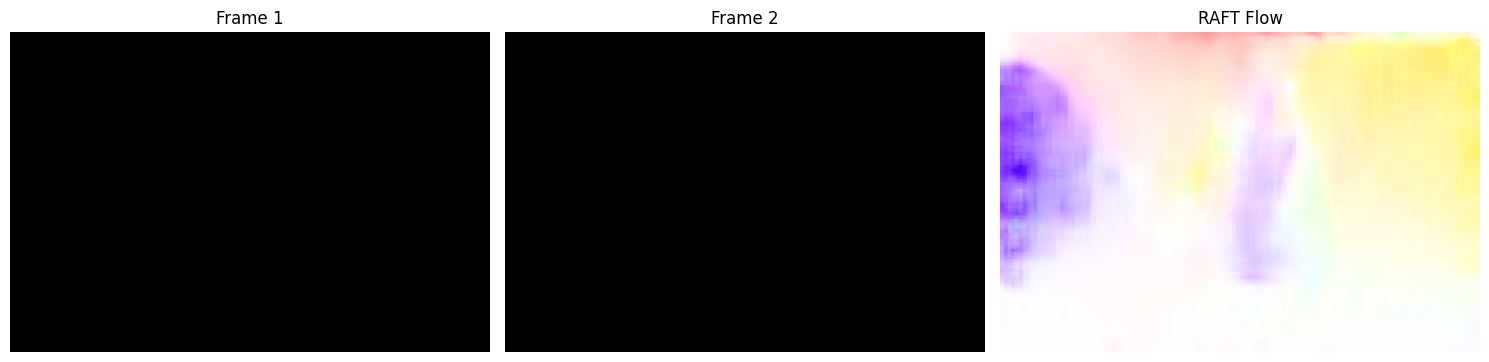


  Video: Test002 (180 frames)
Video: Test002 | obj: 14, fg: 1, total: 15


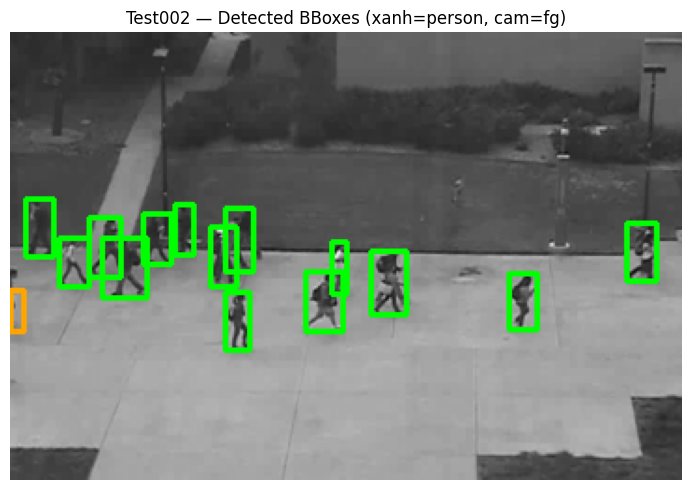

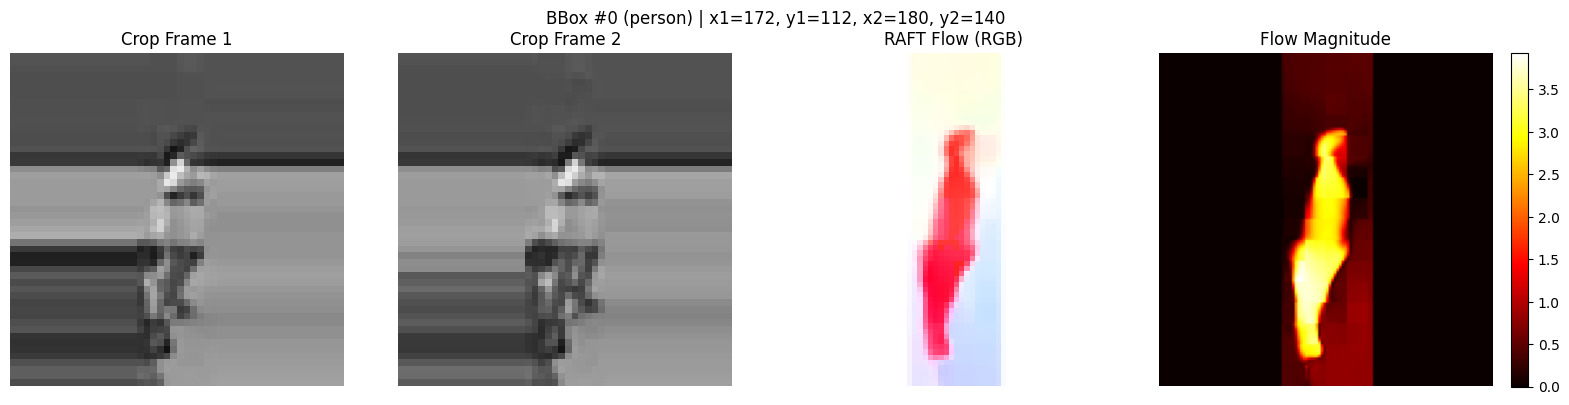

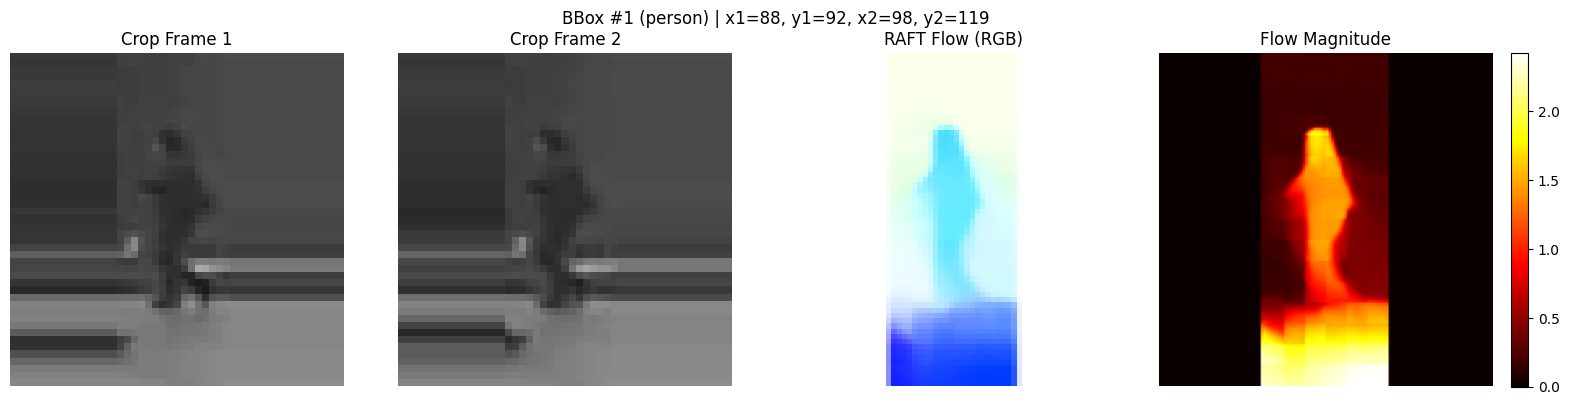

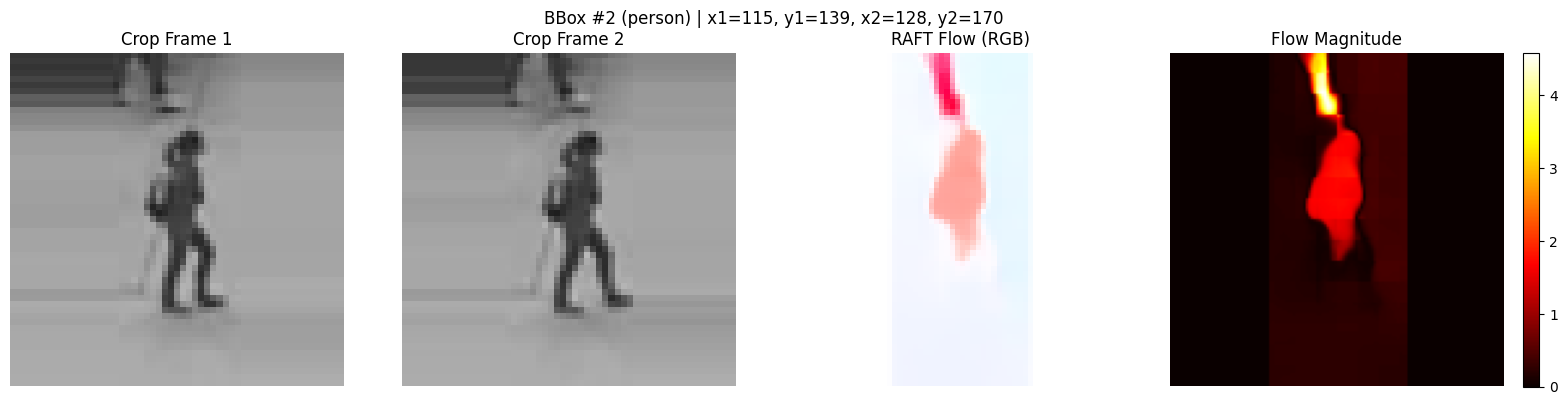

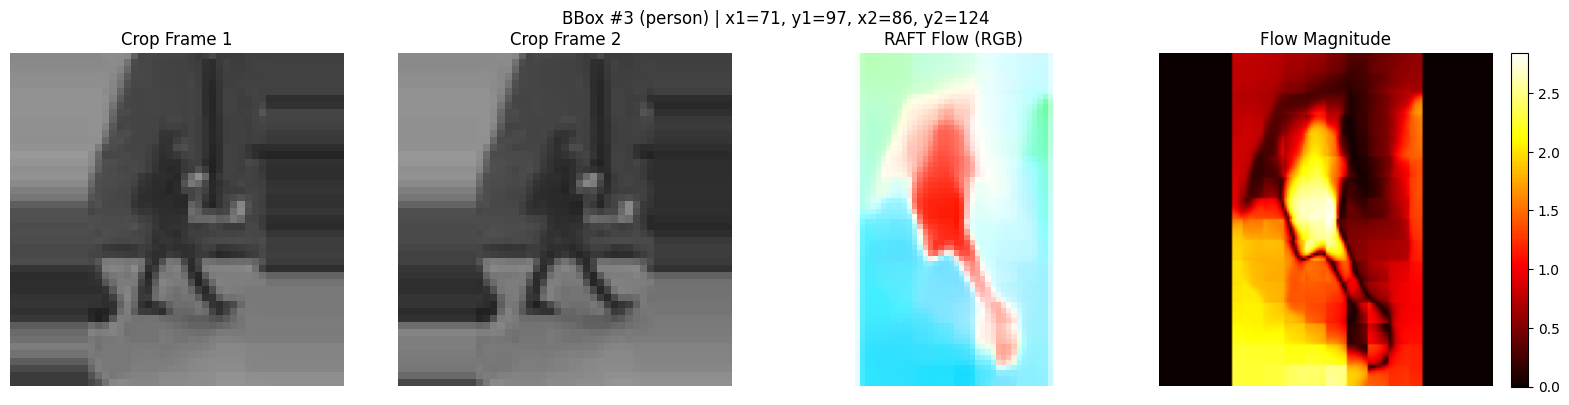

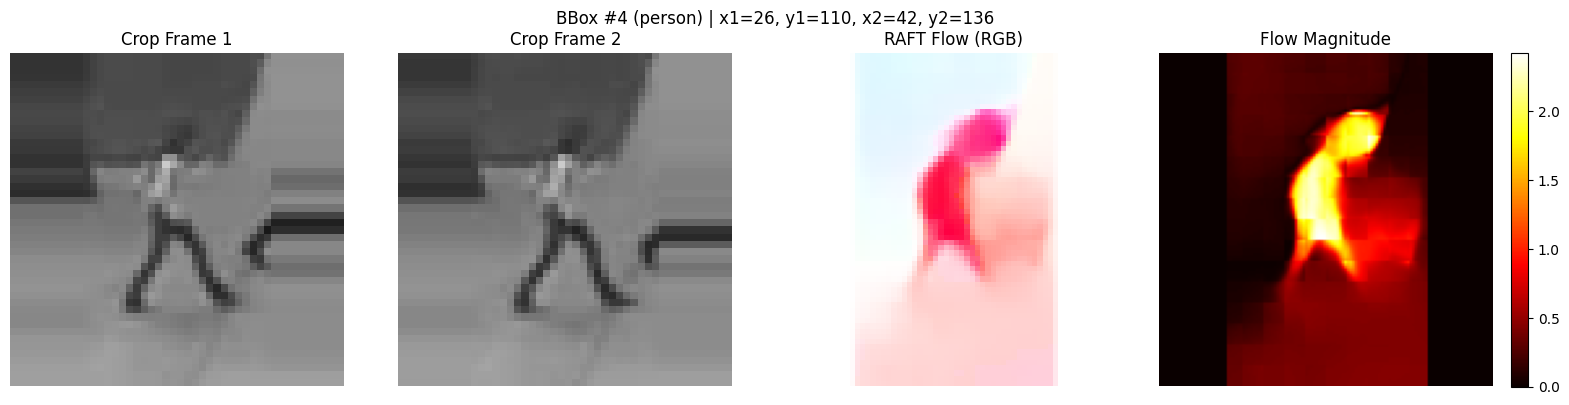

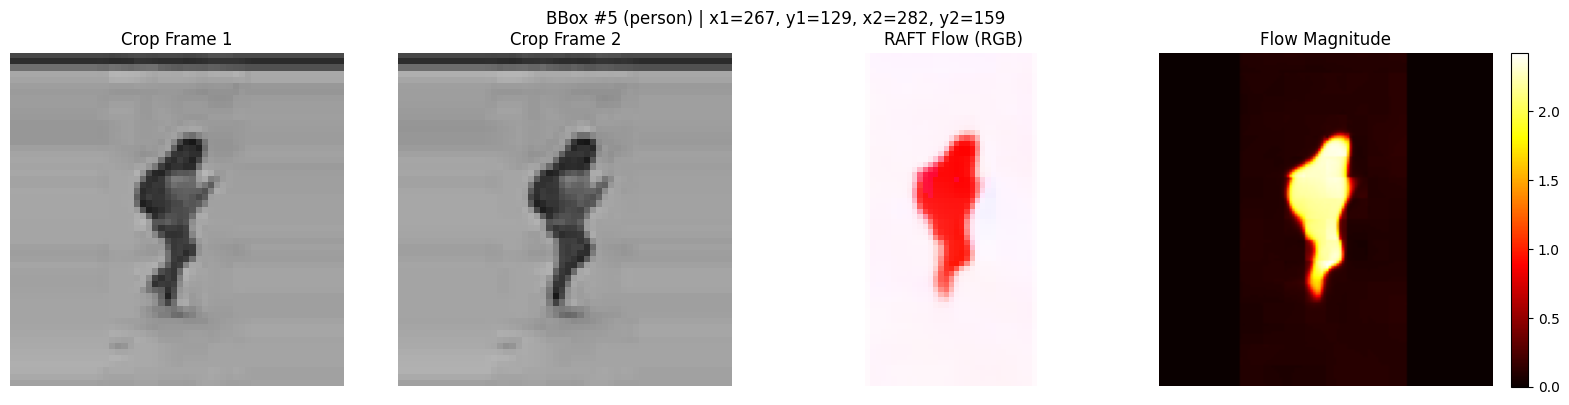

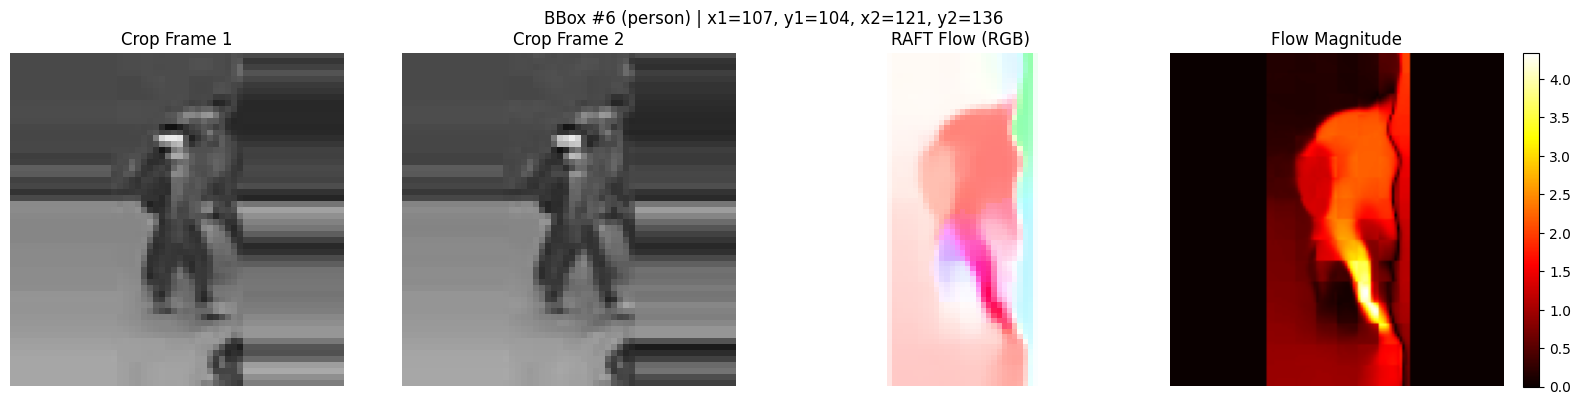

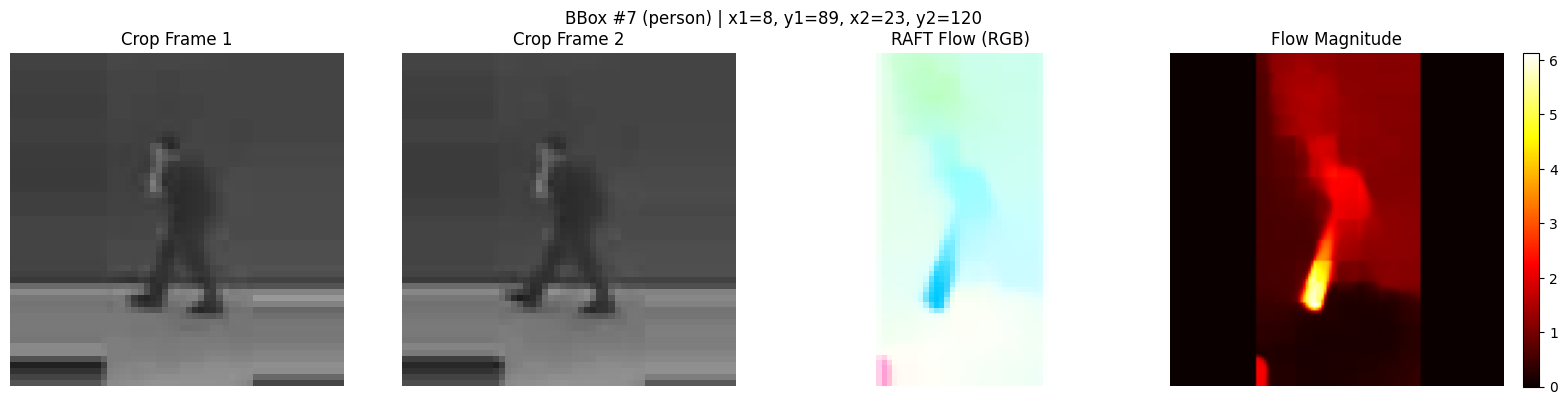

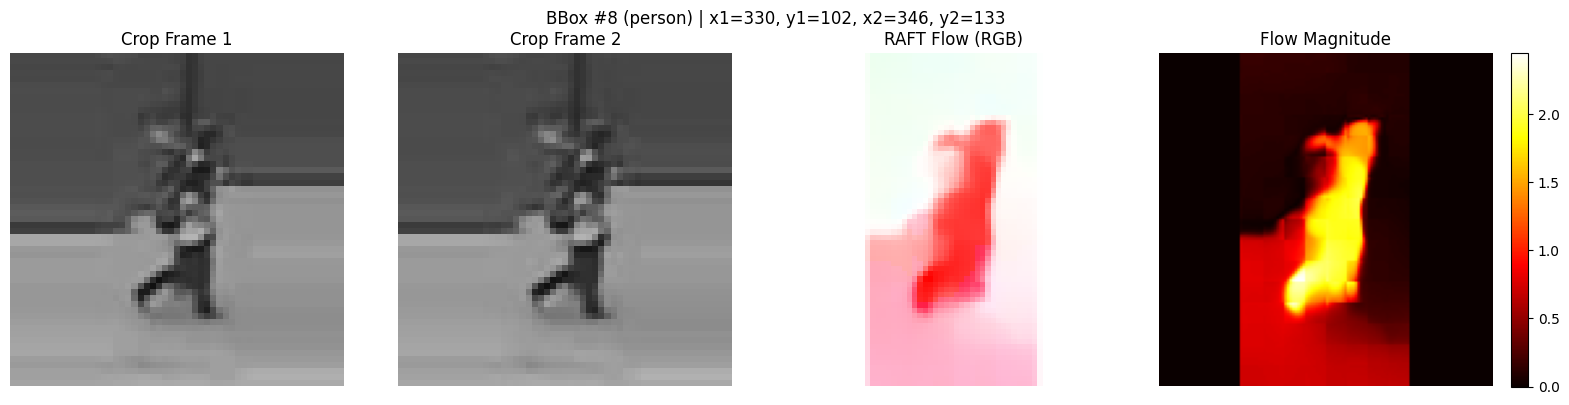

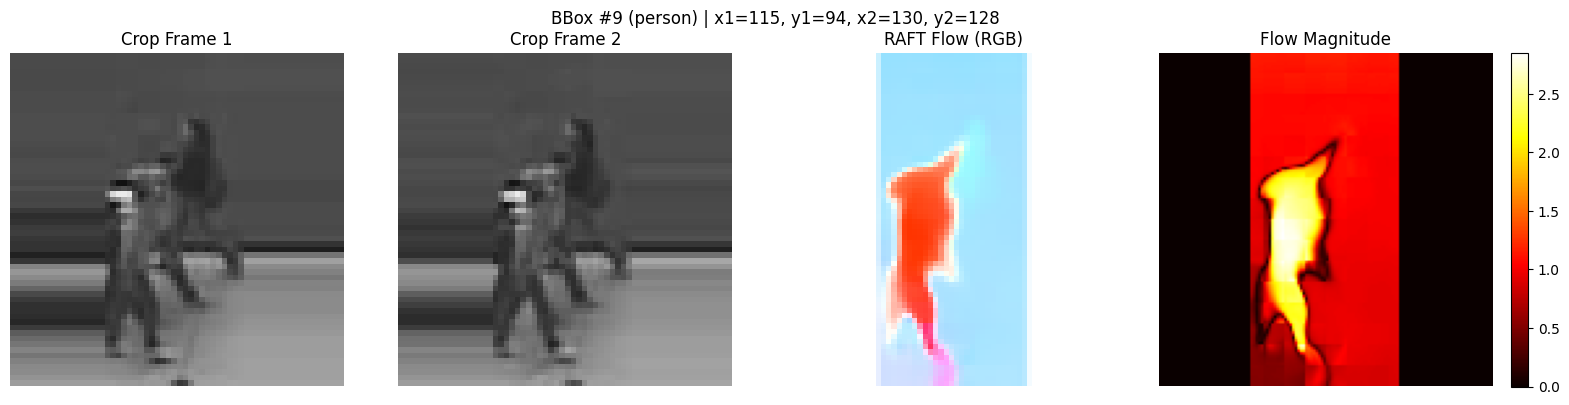

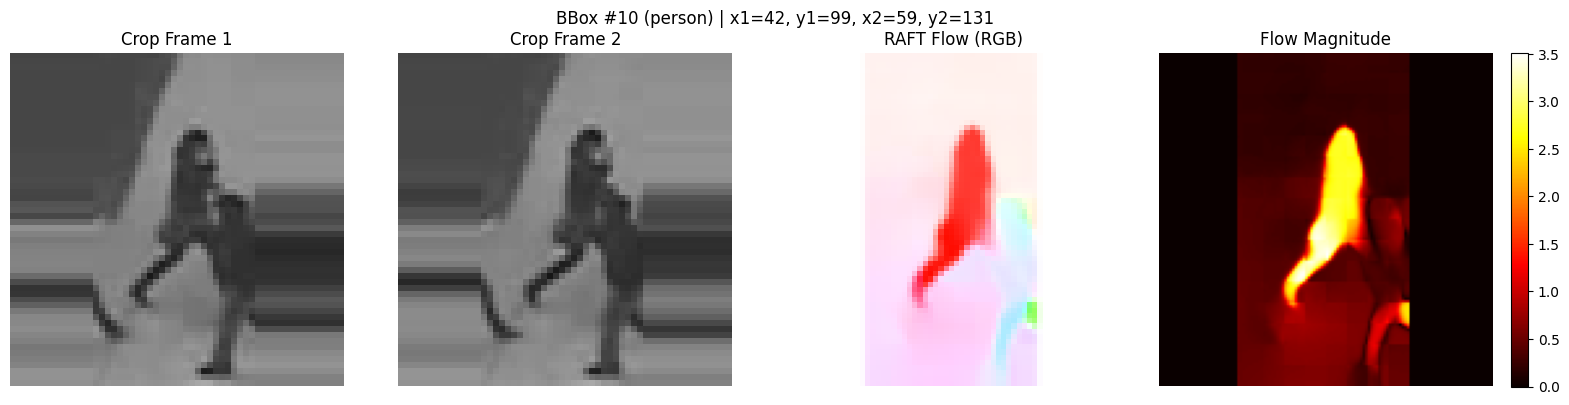

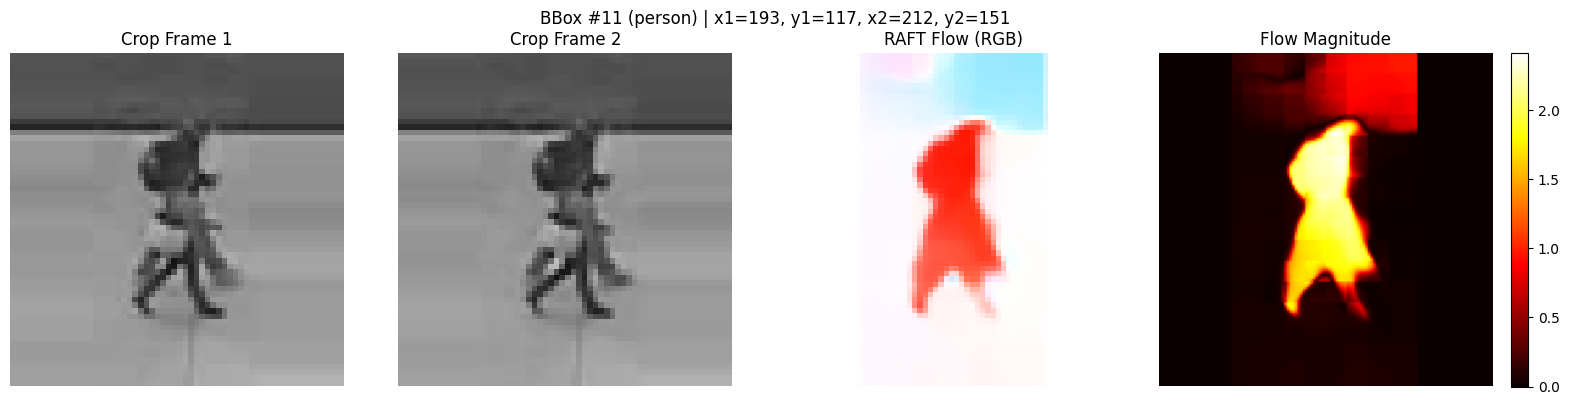

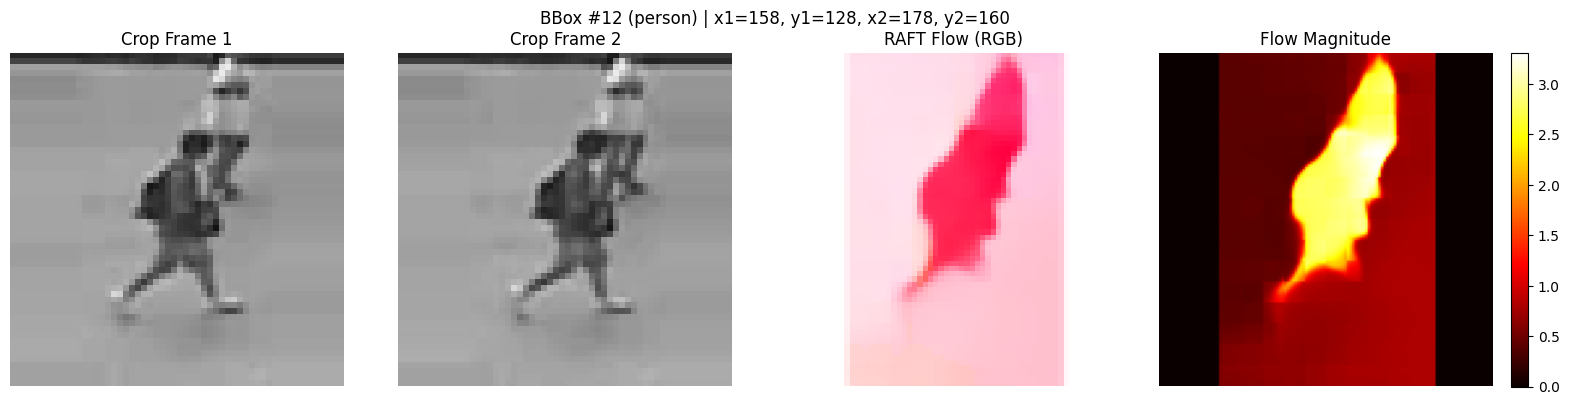

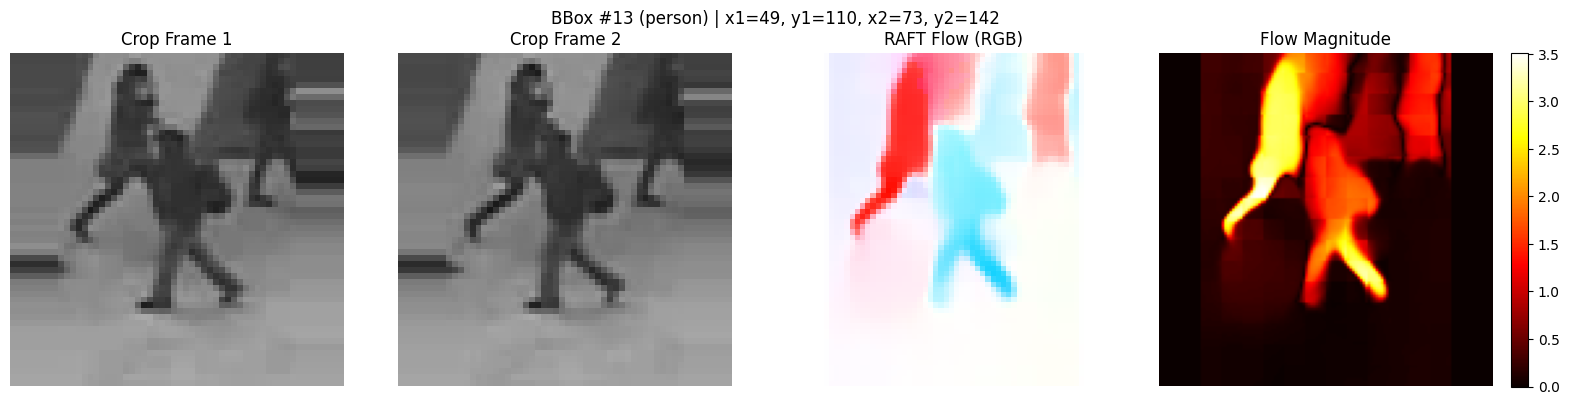

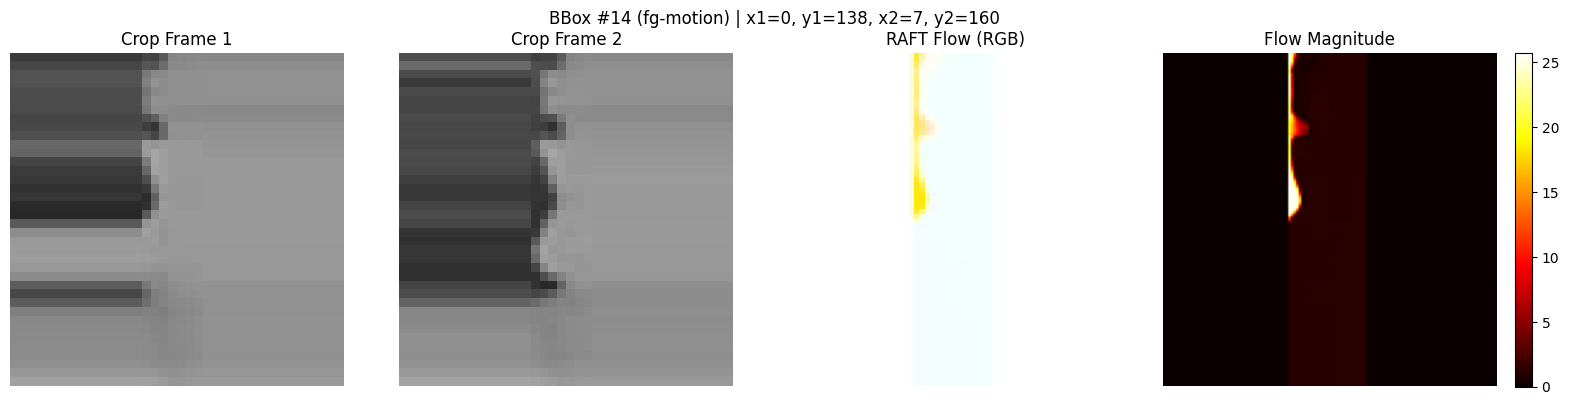

In [12]:
# Visualize 3 video đầu tiên
N_VIDEOS = 3

for vname in video_list[:N_VIDEOS]:
    frames = sorted(video_frames[vname])
    print(f"\n{'='*60}")
    print(f"  Video: {vname} ({len(frames)} frames)")
    print(f"{'='*60}")

    visualize_bbox_flow(
        video_name      = vname,
        frame_paths     = frames,
        detector        = detector,
        raft_model      = raft_model,
        raft_transforms = raft_transforms,
        cfg             = cfg,
        device          = DEVICE,
        raft_hw         = (RAFT_H, RAFT_W),
        stc_size        = (64, 64),
        max_boxes       = None,
        conf_override   = 0.5,
    )

## 9. Kiểm tra file .npy đã lưu

Verify rằng format output của RAFT giống hệt FlowNet2 gốc.

Số file .npy đã lưu: 3996

File: frame046.bmp.npy
Shape : (240, 360, 2)   ← giống FlowNet2: [H, W, 2]
Dtype : float32
Min/Max: -6.489 / 10.921
Mean magnitude: 2.483 px


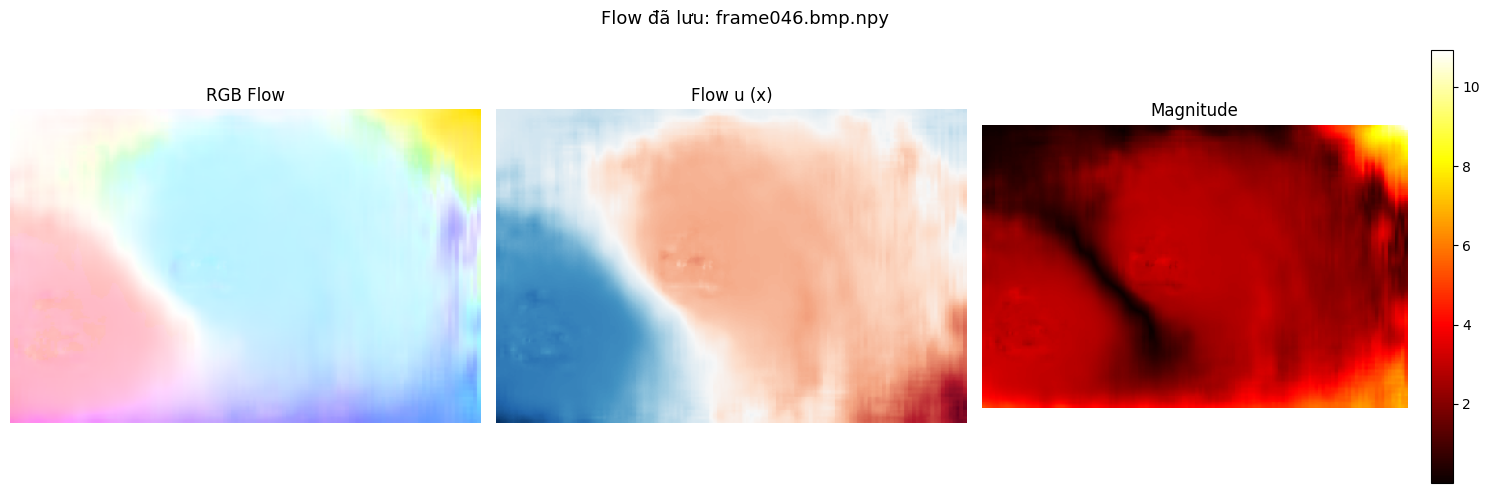

In [13]:
# Tìm file .npy đầu tiên đã lưu
saved_flows = list(FLOWS_ROOT.rglob("*.npy"))
print(f"Số file .npy đã lưu: {len(saved_flows)}")

if saved_flows:
    sample = np.load(str(saved_flows[0]))
    print(f"\nFile: {saved_flows[0].name}")
    print(f"Shape : {sample.shape}   ← giống FlowNet2: [H, W, 2]")
    print(f"Dtype : {sample.dtype}")
    print(f"Min/Max: {sample.min():.3f} / {sample.max():.3f}")
    print(f"Mean magnitude: {np.linalg.norm(sample, axis=-1).mean():.3f} px")

    # Visualize flow đã lưu
    flow_t   = torch.from_numpy(sample).permute(2, 0, 1).unsqueeze(0)
    flow_vis = flow_to_image(flow_t).squeeze(0).permute(1, 2, 0).numpy()
    mag      = np.linalg.norm(sample, axis=-1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Flow đã lưu: {saved_flows[0].name}", fontsize=13)
    axes[0].imshow(flow_vis);                   axes[0].set_title("RGB Flow");   axes[0].axis("off")
    axes[1].imshow(sample[..., 0], cmap="RdBu"); axes[1].set_title("Flow u (x)"); axes[1].axis("off")
    im = axes[2].imshow(mag, cmap="hot");        axes[2].set_title("Magnitude");  axes[2].axis("off")
    plt.colorbar(im, ax=axes[2], fraction=0.046)
    plt.tight_layout(); plt.show()
else:
    print("Chưa có file nào — chạy Cell 6 trước.")

## 10. Tóm tắt thay đổi so với FlowNet2 gốc

| Thành phần | HF2VAD gốc | Bản này (RAFT) |
|---|---|---|
| **Optical flow model** | FlowNet2 (162M params, tự code + CUDA custom ops) | RAFT-Large (torchvision, built-in) |
| **Pretrained weights** | Download thủ công ~500MB từ Drive | `Raft_Large_Weights.DEFAULT` (tự động) |
| **Kiến trúc** | Encoder-Decoder một bước | Iterative refinement (12 steps GRU) |
| **Object detector** | Cascade RCNN (mmdet, cần cài riêng) | Faster R-CNN (torchvision, built-in) |
| **Output format .npy** | `[H, W, 2]` float32 | `[H, W, 2]` float32 **— giống nhau** |
| **Compatibility downstream** | ✅ | ✅ (STC/MemAE đọc được trực tiếp) |
| **Cài đặt** | Phức tạp (build CUDA ops) | Chỉ `pip install torch torchvision` |